In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import re, string, base64, binascii
import unicodedata
import html
from urllib.parse import unquote_plus, urlsplit, parse_qsl
from typing import List, Dict, Tuple


df = pd.read_csv("/content/drive/MyDrive/ATPM/Payloads.csv", encoding="latin1")
# pd.set_option('display.max_colwidth', None)
invalid_rows = []

# =======================
# Decoding / normalization pipeline

JS_UHEX_RE = re.compile(r"\\u([0-9a-fA-F]{4})")
JS_XHEX_RE = re.compile(r"\\x([0-9a-fA-F]{2})")

# Bắt cả decimal và 0x.. (String.fromCharCode / fromCharCode)
FROMCHARCODE_RE = re.compile(
    r"(?:string\.)?fromcharcode\s*\(\s*([0-9xXa-fA-F,\s]+)\s*\)",
    re.IGNORECASE
)

# Base64 token-level (giữ như cũ)
B64_RE = re.compile(
    r"(?<![A-Za-z0-9+/=_-])"
    r"(?=[A-Za-z0-9+/=_-]{16,}(?![A-Za-z0-9+/=_-]))"  # >=16 chars
    r"(?=.*[+/=_-])"                                   # có ít nhất 1 ký tự đặc trưng
    r"(?:[A-Za-z0-9+/_-]{4}){4,}"                       # >=16 chars, bội số 4
    r"(?:[A-Za-z0-9+/_-]{2}==|[A-Za-z0-9+/_-]{3}=)?"
    r"(?![A-Za-z0-9+/=_-])"
)

# HEX token-level: yêu cầu byte-pairs đủ dài + PHẢI có ít nhất 1 chữ a-f
# để tránh match chuỗi chỉ toàn số như 1974630082144363
HEX_RE = re.compile(
    r"(?<![0-9A-Fa-f])"
    r"(?=[0-9A-Fa-f]{16,}(?![0-9A-Fa-f]))"   # tối thiểu 16 hex chars
    r"(?=.*[A-Fa-f])"                        # bắt buộc có chữ a-f
    r"(?:[0-9A-Fa-f]{2}){8,}"
    r"(?![0-9A-Fa-f])"
)

PCT_RE = re.compile(r"%([0-9A-Fa-f]{2})")

def unquote_plus_ascii_only(s: str) -> str:

    def repl(m):
        b = int(m.group(1), 16)
        # chỉ decode các byte ASCII an toàn
        if b < 0x80:
            return chr(b)
        # giữ nguyên percent-encoding cho byte cao
        return m.group(0)

    return PCT_RE.sub(repl, s)

def _has_key_only_params(q):
    # q là list (k, v). key-only thường có v == "" và key không rỗng
    # nhưng keep_blank_values=True nên param dạng a= cũng có v==""
    # ta phân biệt bằng: token key-only thường chứa ';' hoặc 'lt' 'gt' 'quot'... hoặc không giống key bình thường
    for k, v in q:
        if v == "" and k and (";" in k or k.lower().startswith(("quot", "lt", "gt", "#"))):
            return True
    return False

def _parse_query_normal(query: str):
    return parse_qsl(query, keep_blank_values=True)

def _mostly_printable(s: str, min_ratio: float = 0.9) -> bool:
    """Trả True nếu phần lớn ký tự là printable (tránh control chars)."""
    if not s:
        return False
    printable = set(string.printable)
    good = sum(ch in printable for ch in s)
    return (good / len(s)) >= min_ratio

def _js_unicode_unescape(s: str) -> str:
    s = JS_UHEX_RE.sub(lambda m: chr(int(m.group(1), 16)), s)
    return JS_XHEX_RE.sub(lambda m: chr(int(m.group(1), 16)), s)

def _from_charcode_replace(m: re.Match) -> str:
    raw = m.group(1)
    parts = [p.strip() for p in raw.split(",") if p.strip()]

    out = []
    for p in parts:
        try:
            n = int(p, 0)  # hỗ trợ 0x.. và decimal
            if 0 <= n <= 0x10FFFF:
                out.append(chr(n))
        except ValueError:
            return m.group(0)
    decoded = "".join(out)
    return f"string.fromcharcode({decoded})"

def _b64_decode_token(token: str) -> str:
    padded = token + "=" * ((4 - (len(token) & 3)) & 3)
    try:
        decoded = base64.b64decode(padded, validate=False)
        out = decoded.decode("utf-8", errors="ignore")
    except (binascii.Error, ValueError):
        return token

    # Chỉ chấp nhận nếu decode ra chuỗi “nhìn được”
    return out if _mostly_printable(out, 0.9) else token

def _hex_decode_token(token: str) -> str:
    # Chặn số thuần (extra safety)
    if token.isdigit():
        return token

    try:
        decoded = binascii.unhexlify(token)
        out = decoded.decode("utf-8", errors="ignore")
    except (binascii.Error, ValueError):
        return token

    # Chỉ chấp nhận nếu decode ra chuỗi “nhìn được”
    return out if _mostly_printable(out, 0.9) else token

def decode_layers(s: str, rounds: int = 3) -> str:
    if s is None:
        return ""

    s = str(s)
    prev = None

    for _ in range(rounds):
        if s == prev:
            break
        prev = s

        # URL decode + HTML decode
        s = unquote_plus_ascii_only(s)
        s = html.unescape(s)

        # JS escape decode
        s = _js_unicode_unescape(s)
        s = FROMCHARCODE_RE.sub(_from_charcode_replace, s)

        # token-level decode base64/hex (đã có gating)
        s = B64_RE.sub(lambda m: _b64_decode_token(m.group(0)), s)
        s = HEX_RE.sub(lambda m: _hex_decode_token(m.group(0)), s)

        # normalize
        try:
          s = unicodedata.normalize("NFKC", s)
        except:
          pass

    return s

def url_to_payload_core(full_url: str) -> str:
    """
    - Nếu input là querystring thuần (a=b&c=d...), parse_qsl và chỉ decode trên VALUE
      → tránh phá cấu trúc và tránh decode nhầm số/field.
    - Nếu input là URL đầy đủ: lấy query values.
    - Nếu không parse được: decode toàn chuỗi như fallback.
    """
    if full_url is None:
        return ""

    full_url = str(full_url)

    # URL đầy đủ
    try:
        u = urlsplit(full_url)
    except ValueError:
        return decode_layers(full_url, rounds=3)

    if not (u.scheme and u.netloc):
        return decode_layers(full_url, rounds=3)

    q1 = _parse_query_normal(u.query)

    # Nếu parse bình thường có dấu hiệu bị "cắt vụn" do &quot;... => thử HTML-DECODE query rồi parse lại
    if _has_key_only_params(q1):
        q2 = _parse_query_normal(html.unescape(u.query))
        # Nếu q2 “đẹp hơn” (ít key-only hơn / nhiều value hơn) thì dùng q2
        if not _has_key_only_params(q2):
            q = q2
        else:
            q = q1
    else:
        q = q1

    values = [decode_layers(v if v else k, rounds=3) for k, v in q]
    core = "\x1f".join(v for v in values if v).strip()
    if len(core) <= 0:
        # payload in last url path
        core = decode_layers(u.path, rounds=6).strip()

    if u.fragment:
        core = (core + " " + decode_layers(u.fragment, rounds=6)).strip()

    return core if core else decode_layers(full_url, rounds=3)

def preprocess(full_url: str) -> str:
    s = url_to_payload_core(full_url)
    s = s.lower()
    s = s.replace("\r", " ").replace("\n", " ").replace("\t", " ")
    s = re.sub(r"\s+", " ", s).strip()
    return s



# Create New Data Frame
new_df = pd.DataFrame({
    "Class": df["Class"],
    "Payloads": df["Payloads"].apply(preprocess)
})


In [ ]:
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)

# Validate columns
assert "Payloads" in new_df.columns, f"Missing column: Payloads. Found: {list(df.columns)}"
assert "Class" in new_df.columns, f"Missing column: Class. Found: {list(df.columns)}"

# Warn on unknown classes
unknown = new_df["Payloads"].isna()
if unknown.any():
    print("⚠️ Warning: Unknown Payloads values detected. Unique values:")
    print(df.loc[unknown, "Payloads"].astype(str).str.strip().unique()[:20])

def check_duplicates(df):
    print("\n[+] Checking duplicates...")

    # Tổng số duplicate theo Payloads
    dup_mask = df.duplicated(subset=["Payloads"], keep=False)
    dup_count = dup_mask.sum()
    dup_rows = df.loc[dup_mask]

    print(f"Total duplicate rows (based on Payloads): {dup_count}")

    if dup_count > 0:
        # Số Payloads bị trùng (unique)
        dup_unique = df.loc[dup_mask, "Payloads"].nunique()
        print(f"Unique duplicated Payloads: {dup_unique}")

        # Đếm số lượng label trong các row duplicate
        label_counts_in_duplicates = dup_rows["Class"].value_counts()
        print("\n[+] Duplicate label counts:")
        print(label_counts_in_duplicates)

        # Nếu muốn xem số lượng label unique trong duplicate
        print(f"\nTotal unique labels in duplicates: {dup_rows['Class'].nunique()}")

        conflict = (
            df.loc[dup_mask]
            .groupby("Payloads")["Class"]
            .nunique()
        )

        conflict_cases = conflict[conflict > 1]
        if len(conflict_cases) > 0:
            print("\n⚠️ Found label conflicts in duplicated Payloads!")
            print(f"\nConflict Payloads: {len(conflict_cases)}")

            # print("\n===== Conflict Details =====")

            # for payload in conflict_cases.index:
            #     rows = df[df["Payloads"] == payload]
            #     print(f"\nPayload: {payload}")
            #     print(f"Indexes: {rows.index.tolist()}")
            #     print(f"Classes: {rows['Class'].tolist()}")

        else:
            print("No label conflicts in duplicates.")

    else:
        print("No duplicate Payloads found.")
check_duplicates(new_df)

# tìm payload conflict trên dữ liệu gốc
dup_mask = new_df.duplicated(subset=["Payloads"], keep=False)
conflict_payloads = (
    new_df.loc[dup_mask]
    .groupby("Payloads")["Class"]
    .nunique()
)
conflict_payloads = conflict_payloads[conflict_payloads > 1].index

# loại bỏ toàn bộ payload conflict
df_no_conflict = new_df[~new_df["Payloads"].isin(conflict_payloads)].copy()

# sau đó mới drop duplicate bình thường
df_clean = df_no_conflict.drop_duplicates(subset=["Payloads"]).dropna(subset=["Payloads"])

print(f"\nTotal original rows: {len(new_df)}")
print(f"Total clean rows: {len(df_clean)}")

check_duplicates(df_clean)


# Đếm số lượng từng class
counts = df_clean["Class"].value_counts()

print("\n[+] Class counts:")
print(counts)

# Tính tỷ lệ %
ratios = df_clean["Class"].value_counts(normalize=True) * 100

print("\n[+] Class ratios (%):")
print(ratios)



[+] Checking duplicates...
Total duplicate rows (based on Payloads): 6601
Unique duplicated Payloads: 1195

[+] Duplicate label counts:
Class
Malicious    6597
Benign          4
Name: count, dtype: int64

Total unique labels in duplicates: 2

⚠️ Found label conflicts in duplicated Payloads!

Conflict Payloads: 1

Total original rows: 43217
Total clean rows: 37810

[+] Checking duplicates...
Total duplicate rows (based on Payloads): 0
No duplicate Payloads found.

[+] Class counts:
Class
Benign       28065
Malicious     9745
Name: count, dtype: int64

[+] Class ratios (%):
Class
Benign       74.226395
Malicious    25.773605
Name: proportion, dtype: float64


In [ ]:
import re, string, base64, binascii
import unicodedata
import html
from urllib.parse import unquote_plus, urlsplit, parse_qsl
from typing import List, Dict, Tuple

import pandas as pd

# ---------------- Config ----------------
OUTPUT_CSV = "/content/drive/MyDrive/ATPM/features.csv"
TEXT_COL = "Payloads"
CLASS_COL = "Class"
KEEP_ORIGINAL = True
# ----------------------------------------

# =======================
# Table 1: Structural features
# =======================
PUNCTUATION_CHARS: List[str] = [
    "&", "%", "/", "\\", "+", "'", "?", "!", ";", "#", "=", "[", "]", "$",
    "(", ")", "^", "*", ",", "-", "<", ">", "@", "_", ":", "{", "}", "~", ".",
    " ", "|", "¦", '"',
]

PUNCTUATION_COMBOS: List[str] = ["><", "'\"><", "[]", "==", "&#"]


def safe_feature_name(token: str, prefix: str) -> str:
    mapping = {
        "&": "amp",
        "%": "pct",
        "/": "slash",
        "\\": "bslash",
        "+": "plus",
        "'": "squote",
        '"': "dquote",
        "?": "qmark",
        "!": "emark",
        ";": "semi",
        "#": "hash",
        "=": "eq",
        "[": "lbrack",
        "]": "rbrack",
        "$": "dollar",
        "(": "lparen",
        ")": "rparen",
        "^": "caret",
        "*": "star",
        ",": "comma",
        "-": "dash",
        "<": "lt",
        ">": "gt",
        "@": "at",
        "_": "underscore",
        ":": "colon",
        "{": "lbrace",
        "}": "rbrace",
        "~": "tilde",
        ".": "dot",
        " ": "space",
        "|": "pipe",
        "¦": "brokenbar",
    }
    return f"{prefix}_" + "_".join(mapping.get(ch, f"u{ord(ch)}") for ch in token)


# =======================
# Table 2: Keyword features (word-boundary safe where appropriate)
# =======================

WORD_PATTERNS: List[Tuple[str, re.Pattern]] = [
    # Objects
    ("obj_document", re.compile(r"\bdocument\b")),
    ("obj_window", re.compile(r"\bwindow\b")),
    ("obj_iframe", re.compile(r"\biframe\b")),
    ("obj_location", re.compile(r"\blocation\b")),
    ("obj_this", re.compile(r"\bthis\b")),

    # Events
    ("evt_onload", re.compile(r"\bonload\b")),
    ("evt_onerror", re.compile(r"\bonerror\b")),

    # Methods
    ("mth_createelement", re.compile(r"\bcreateelement\b")),
    ("mth_fromcharcode", re.compile(r"\bstring\.fromcharcode\b")),
    ("mth_search", re.compile(r"\bsearch\b")),

    # Attributes (word boundary helps avoid matching "srcset", etc.)
    ("attr_src", re.compile(r"\bsrc\b")),
    ("attr_href", re.compile(r"\bhref\b")),
    ("attr_cookie", re.compile(r"\bcookie\b")),

    # Reserved
    ("kw_var", re.compile(r"\bvar\b")),

    # Protocol
    ("proto_http", re.compile(r"\bhttp\b")),
]

LITERAL_PATTERNS: List[Tuple[str, str]] = [
    # Tags
    ("tag_div", "div"),
    ("tag_img", "img"),
    ("tag_script", "<script"),

    # Functions
    ("fn_eval", "eval("),

    # External file
    ("ext_js", ".js"),
]




# =======================
# Feature extraction (binary presence)
# =======================

def char_type_ratios_ascii(s: str):
    if s is None:
        return 0.0, 0.0, 0.0

    s = str(s)

    # bỏ separator nếu bạn dùng \x1f để join query values
    s = s.replace("\x1f", "")

    n = len(s)
    if n == 0:
        return 0.0, 0.0, 0.0

    letters = 0
    numbers = 0
    symbols = 0

    for ch in s:
        if ('A' <= ch <= 'Z') or ('a' <= ch <= 'z'):
            letters += 1
        elif '0' <= ch <= '9':
            numbers += 1
        else:
            symbols += 1

    return letters / n, numbers / n, symbols / n

def extract_features(s: str) -> Dict[str, int | float]:
    feats: Dict[str, int | float] = {}

    # ======================
    # ASCII Ratio Features
    # ======================
    lr, nr, sr = char_type_ratios_ascii(s)

    feats["letters_ratio"] = lr
    feats["numbers_ratio"] = nr
    feats["symbols_ratio"] = sr

    # ======================
    # Table 1: Structural
    # ======================
    for ch in PUNCTUATION_CHARS:
        feats[safe_feature_name(ch, "punc")] = 1 if ch in s else 0

    for combo in PUNCTUATION_COMBOS:
        feats[safe_feature_name(combo, "combo")] = 1 if combo in s else 0

    # ======================
    # Table 2: Keyword
    # ======================
    for name, pat in WORD_PATTERNS:
        feats[name] = 1 if pat.search(s) else 0

    for name, lit in LITERAL_PATTERNS:
        feats[name] = 1 if lit in s else 0

    return feats

# =======================
# Calculate Readability Feature
# =======================


# ---------- Readability heuristic ----------
VOWELS = set("aeiouAEIOU")
TOKEN_SPLIT_RE = re.compile(r"[^A-Za-z0-9]+")

def tokenize_payload_readability(payload: str):
    return [t for t in TOKEN_SPLIT_RE.split(payload) if t]

def payload_human_readable_by_percentage(payload: str) -> int:
    """
    Trả về 1 nếu payload 'giống văn bản người đọc' theo các ngưỡng heuristic,
    ngược lại trả 0. (dạng int để làm feature)
    """
    words = tokenize_payload_readability(payload)
    total = len(words)
    if total == 0:
        return 0

    alpha_ok = vowel_ok = length_ok = repetition_ok = 0

    # ceil thresholds
    need_alpha  = int(0.45 * total + 0.999999)
    need_vowel  = int(0.40 * total + 0.999999)
    need_length = int(0.70 * total + 0.999999)
    need_rep    = int(0.80 * total + 0.999999)

    for i, w in enumerate(words, start=1):
        n_total = len(w)

        if n_total < 15:
            length_ok += 1

        # 1-pass scan: count alpha + vowels + detect >=3 consecutive
        n_alpha = 0
        n_vowel = 0
        rep_bad = False

        prev = None
        run = 0

        for ch in w:
            # consecutive repetition
            if ch == prev:
                run += 1
                if run >= 3:
                    rep_bad = True
            else:
                prev = ch
                run = 1

            # ASCII alpha (consistent with your tokenization A-Za-z0-9)
            if ('A' <= ch <= 'Z') or ('a' <= ch <= 'z'):
                n_alpha += 1
                if ch in VOWELS:
                    n_vowel += 1

        if not rep_bad:
            repetition_ok += 1

        if n_total > 0 and (n_alpha / n_total) > 0.70:
            alpha_ok += 1

        if n_alpha > 0:
            vr = n_vowel / n_alpha
            if 0.20 < vr < 0.60:
                vowel_ok += 1

        # early exit
        remaining = total - i
        if alpha_ok + remaining < need_alpha:
            return 0
        if vowel_ok + remaining < need_vowel:
            return 0
        if length_ok + remaining < need_length:
            return 0
        if repetition_ok + remaining < need_rep:
            return 0

    return int(
        alpha_ok >= need_alpha and
        vowel_ok >= need_vowel and
        length_ok >= need_length and
        repetition_ok >= need_rep
    )


# =======================
# Main run (Colab cell)
# =======================
# df = read_csv_robust(INPUT_CSV)
df = df_clean.copy().reset_index(drop=True)
# Map Class -> label (0/1)
df["label"] = df[CLASS_COL].astype(str).str.strip().str.lower().map({
    "malicious": 1,
    "benign": 0,
})

# Preprocess URLs into payload core
text_series = df[TEXT_COL].map(preprocess)
feat_df = pd.DataFrame(list(text_series.map(extract_features)))

# Readability feature (0/1)
readability = text_series.map(payload_human_readable_by_percentage)

# Merge + Save
out = pd.concat([feat_df, readability.rename("readability"), df["label"]], axis=1)
out.to_csv(OUTPUT_CSV, index=False)

print("Saved:", OUTPUT_CSV)
print("Rows:", out.shape[0], "| Added feature cols:", feat_df.shape[1])
out.head()


Saved: /content/drive/MyDrive/ATPM/features.csv
Rows: 37810 | Added feature cols: 61


,letters_ratio,numbers_ratio,symbols_ratio,punc_amp,punc_pct,punc_slash,punc_bslash,punc_plus,punc_squote,punc_qmark,...,attr_cookie,kw_var,proto_http,tag_div,tag_img,tag_script,fn_eval,ext_js,readability,label
0,0.717391,0.000000,0.282609,0,0,1,0,0,0,0,...,1,0,0,0,0,1,0,0,0,1
1,0.725000,0.012500,0.262500,0,0,1,0,0,0,0,...,1,0,0,0,0,1,0,0,0,1
2,0.785714,0.047619,0.166667,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,1,1
3,0.807882,0.004926,0.187192,0,0,1,1,0,0,0,...,1,0,0,0,0,1,0,0,1,1
4,0.687500,0.000000,0.312500,0,0,1,0,0,1,0,...,0,0,1,0,0,0,0,0,1,1


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

# 1. Đọc dữ liệu
df = pd.read_csv("/content/drive/MyDrive/ATPM/features.csv")  # đổi thành file của bạn

# 2. Kiểm tra nhanh phân bố label (optional)
print(df["label"].value_counts(normalize=True))

# 3. Chia train/test với stratify
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["label"]   # QUAN TRỌNG
)

# 4. Kiểm tra lại phân bố
print("\nTrain distribution:")
print(train_df["label"].value_counts(normalize=True))

print("\nTest distribution:")
print(test_df["label"].value_counts(normalize=True))

# 5. Lưu file
train_df.to_csv("/content/drive/MyDrive/ATPM/train.csv", index=False)
test_df.to_csv("/content/drive/MyDrive/ATPM/test.csv", index=False)

print("\nDone! Saved train.csv and test.csv")

label
0    0.742264
1    0.257736
Name: proportion, dtype: float64

Train distribution:
label
0    0.742264
1    0.257736
Name: proportion, dtype: float64

Test distribution:
label
0    0.742264
1    0.257736
Name: proportion, dtype: float64

Done! Saved train.csv and test.csv


In [ ]:
# ======================================
# CONFIG + DATA LOADING
# ======================================

import os
import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

# ------------------------
# DATA CONFIG
# ------------------------
DATA_PATH = "/content/drive/MyDrive/ATPM/features.csv"

TARGET_COLUMN = "label"
DROP_EXTRA_COLUMNS = ["Payloads", "Payloads_normalized", "Class"]

ENCODING = "latin1"

# ------------------------
# EXPERIMENT CONFIG
# ------------------------
N_SPLITS = 10
RANDOM_STATE = 42

SCORING = "f1"
# ------------------------
# LOAD DATA
# ------------------------
assert os.path.exists(DATA_PATH), f"File not found: {DATA_PATH}"

df = pd.read_csv(DATA_PATH, encoding=ENCODING)

assert TARGET_COLUMN in df.columns, f"Missing target column: {TARGET_COLUMN}"

y = df[TARGET_COLUMN].astype(int)

drop_cols = [TARGET_COLUMN]
for c in DROP_EXTRA_COLUMNS:
    if c in df.columns:
        drop_cols.append(c)

X = df.drop(columns=drop_cols)

print("="*60)
print("DATA LOADED")
print("="*60)
print("Shape:", X.shape)
print("Class distribution:")
print(y.value_counts(normalize=False))
print("\nClass ratio:")
print(y.value_counts(normalize=True))


# ================================
# GRID SEARCH FOR HYPERPARAMETERS
# ================================

from sklearn.model_selection import GridSearchCV, StratifiedKFold

print("\n" + "="*80)
print("RUNNING GRID SEARCH")
print("="*80)

cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

param_grids = {

    "SVM linear": {
        "model": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LinearSVC(class_weight="balanced", random_state=RANDOM_STATE))
        ]),
        "params": {
            "clf__C": [0.01, 0.1, 1, 10]
        }
    },

    "SVM Poly": {
        "model": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", SVC(
                kernel="poly",
                class_weight="balanced"
            ))
        ]),
        "params": {
            "clf__C": [0.01, 1, 10, 100],
            "clf__degree": [2, 3],
            "clf__gamma": ["scale", "auto"]
        }
    },

    "KNN": {
        "model": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", KNeighborsClassifier())
        ]),
        "params": {
            "clf__n_neighbors": [3, 5, 7],
            "clf__weights": ["uniform", "distance"]
        }
    },

    "Random Forest": {
        "model": RandomForestClassifier(
            class_weight="balanced_subsample",
            random_state=RANDOM_STATE,
            n_jobs=-1
        ),
        "params": {
            "n_estimators": [60, 100, 200],
            "max_depth": [None, 10, 20],
            "min_samples_split": [2, 3, 5]
        }
    }
}

best_models = {}

for name, cfg in param_grids.items():

    print("\n" + "-"*60)
    print(f"Grid Search: {name}")
    print("-"*60)

    grid = GridSearchCV(
        estimator=cfg["model"],
        param_grid=cfg["params"],
        scoring="f1",
        cv=cv,
        n_jobs=1,
        verbose=1
    )

    grid.fit(X, y)

    print(f"\nBest F1: {grid.best_score_:.4f}")
    print("Best Params:", grid.best_params_)

    best_models[name] = grid.best_estimator_

print("\n" + "="*80)
print("GRID SEARCH DONE")
print("="*80)

DATA LOADED
Shape: (37810, 62)
Class distribution:
label
0    28065
1     9745
Name: count, dtype: int64

Class ratio:
label
0    0.742264
1    0.257736
Name: proportion, dtype: float64

RUNNING GRID SEARCH

------------------------------------------------------------
Grid Search: SVM linear
------------------------------------------------------------
Fitting 10 folds for each of 4 candidates, totalling 40 fits

Best F1: 0.9723
Best Params: {'clf__C': 0.1}

------------------------------------------------------------
Grid Search: SVM Poly
------------------------------------------------------------
Fitting 10 folds for each of 16 candidates, totalling 160 fits

Best F1: 0.9865
Best Params: {'clf__C': 10, 'clf__degree': 3, 'clf__gamma': 'scale'}

------------------------------------------------------------
Grid Search: KNN
------------------------------------------------------------
Fitting 10 folds for each of 6 candidates, totalling 60 fits

Best F1: 0.9861
Best Params: {'clf__n_neigh

In [ ]:
# ======================================
# CONFIG + DATA LOADING
# ======================================

import os
import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

# ------------------------
# DATA CONFIG
# ------------------------
DATA_PATH = "/content/drive/MyDrive/ATPM/features.csv"

TARGET_COLUMN = "label"
DROP_EXTRA_COLUMNS = ["Payloads", "Payloads_normalized", "Class"]

ENCODING = "latin1"

# ------------------------
# EXPERIMENT CONFIG
# ------------------------
N_SPLITS = 5
RANDOM_STATE = 42

SCORING = "f1"
# ------------------------
# LOAD DATA
# ------------------------
assert os.path.exists(DATA_PATH), f"File not found: {DATA_PATH}"

df = pd.read_csv(DATA_PATH, encoding=ENCODING)

assert TARGET_COLUMN in df.columns, f"Missing target column: {TARGET_COLUMN}"

y = df[TARGET_COLUMN].astype(int)

drop_cols = [TARGET_COLUMN]
for c in DROP_EXTRA_COLUMNS:
    if c in df.columns:
        drop_cols.append(c)

X = df.drop(columns=drop_cols)

print("="*60)
print("DATA LOADED")
print("="*60)
print("Shape:", X.shape)
print("Class distribution:")
print(y.value_counts(normalize=False))
print("\nClass ratio:")
print(y.value_counts(normalize=True))


# ================================
# GRID SEARCH FOR HYPERPARAMETERS
# ================================

from sklearn.model_selection import GridSearchCV, StratifiedKFold

print("\n" + "="*80)
print("RUNNING GRID SEARCH")
print("="*80)

cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

param_grids = {

    "SVM linear": {
        "model": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LinearSVC(class_weight="balanced", random_state=RANDOM_STATE))
        ]),
        "params": {
            "clf__C": [0.01, 0.1, 1, 10]
        }
    },

    "SVM Poly": {
        "model": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", SVC(
                kernel="poly",
                class_weight="balanced"
            ))
        ]),
        "params": {
            "clf__C": [0.01, 1, 10, 100],
            "clf__degree": [2, 3],
            "clf__gamma": ["scale", "auto"]
        }
    },

    "KNN": {
        "model": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", KNeighborsClassifier())
        ]),
        "params": {
            "clf__n_neighbors": [3, 5, 7],
            "clf__weights": ["uniform", "distance"]
        }
    },

    "Random Forest": {
        "model": RandomForestClassifier(
            class_weight="balanced_subsample",
            random_state=RANDOM_STATE,
            n_jobs=-1
        ),
        "params": {
            "n_estimators": [60, 100, 200],
            "max_depth": [None, 10, 20],
            "min_samples_split": [2, 3, 5]
        }
    }
}

best_models = {}

for name, cfg in param_grids.items():

    print("\n" + "-"*60)
    print(f"Grid Search: {name}")
    print("-"*60)

    grid = GridSearchCV(
        estimator=cfg["model"],
        param_grid=cfg["params"],
        scoring="f1",
        cv=cv,
        n_jobs=1,
        verbose=1
    )

    grid.fit(X, y)

    print(f"\nBest F1: {grid.best_score_:.4f}")
    print("Best Params:", grid.best_params_)

    best_models[name] = grid.best_estimator_

print("\n" + "="*80)
print("GRID SEARCH DONE")
print("="*80)

DATA LOADED
Shape: (37810, 62)
Class distribution:
label
0    28065
1     9745
Name: count, dtype: int64

Class ratio:
label
0    0.742264
1    0.257736
Name: proportion, dtype: float64

RUNNING GRID SEARCH

------------------------------------------------------------
Grid Search: SVM linear
------------------------------------------------------------
Fitting 5 folds for each of 4 candidates, totalling 20 fits

Best F1: 0.9717
Best Params: {'clf__C': 0.01}

------------------------------------------------------------
Grid Search: SVM Poly
------------------------------------------------------------
Fitting 5 folds for each of 16 candidates, totalling 80 fits

Best F1: 0.9868
Best Params: {'clf__C': 10, 'clf__degree': 3, 'clf__gamma': 'scale'}

------------------------------------------------------------
Grid Search: KNN
------------------------------------------------------------
Fitting 5 folds for each of 6 candidates, totalling 30 fits

Best F1: 0.9854
Best Params: {'clf__n_neighbor

Dataset shape: (37810, 62)

Learning Curve: SVM linear (C=0.1)
Train size:   3402 | Train F1: 0.9819 ± 0.0047 | CV F1: 0.9688 ± 0.0022
Train size:  11059 | Train F1: 0.9757 ± 0.0016 | CV F1: 0.9723 ± 0.0056
Train size:  18715 | Train F1: 0.9746 ± 0.0009 | CV F1: 0.9723 ± 0.0045
Train size:  26372 | Train F1: 0.9742 ± 0.0011 | CV F1: 0.9721 ± 0.0041
Train size:  34029 | Train F1: 0.9738 ± 0.0011 | CV F1: 0.9722 ± 0.0045


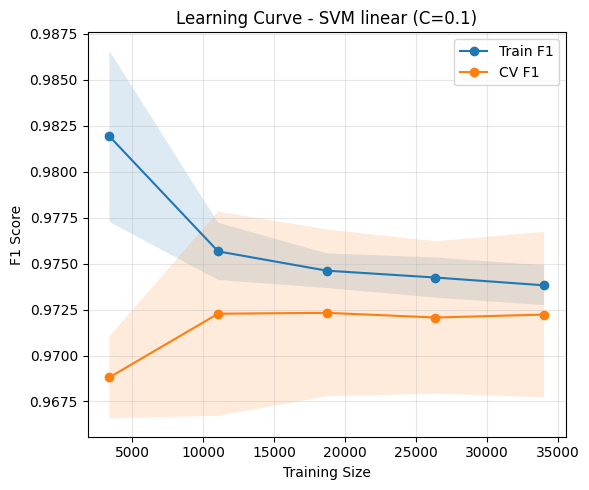


Learning Curve: SVM Poly (deg=3, C=10)
Train size:   3402 | Train F1: 0.9969 ± 0.0011 | CV F1: 0.9716 ± 0.0043
Train size:  11059 | Train F1: 0.9963 ± 0.0006 | CV F1: 0.9818 ± 0.0026
Train size:  18715 | Train F1: 0.9961 ± 0.0007 | CV F1: 0.9841 ± 0.0014
Train size:  26372 | Train F1: 0.9958 ± 0.0005 | CV F1: 0.9855 ± 0.0018
Train size:  34029 | Train F1: 0.9957 ± 0.0002 | CV F1: 0.9865 ± 0.0023


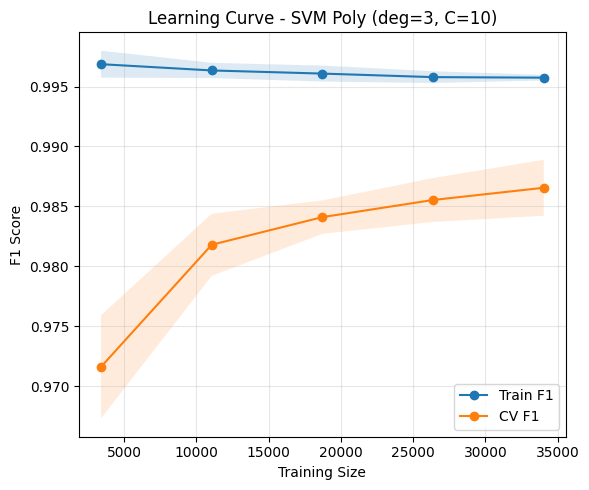


Learning Curve: KNN (k=5, distance)
Train size:   3402 | Train F1: 0.9997 ± 0.0004 | CV F1: 0.9693 ± 0.0041
Train size:  11059 | Train F1: 0.9996 ± 0.0003 | CV F1: 0.9794 ± 0.0030
Train size:  18715 | Train F1: 0.9994 ± 0.0003 | CV F1: 0.9823 ± 0.0027
Train size:  26372 | Train F1: 0.9993 ± 0.0001 | CV F1: 0.9842 ± 0.0018
Train size:  34029 | Train F1: 0.9993 ± 0.0001 | CV F1: 0.9861 ± 0.0019


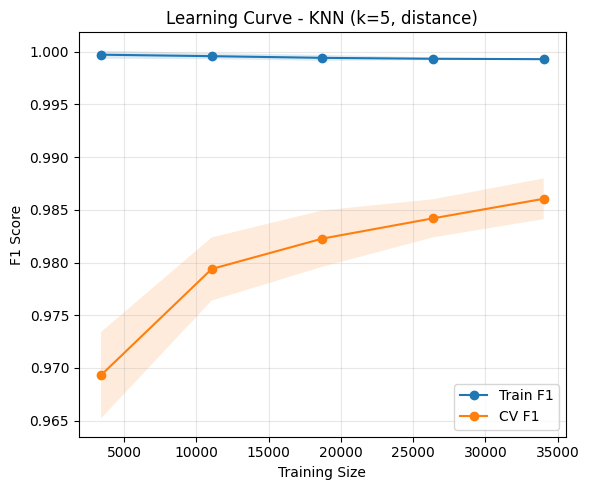


Learning Curve: Random Forest (n=200)
Train size:   3402 | Train F1: 0.9996 ± 0.0005 | CV F1: 0.9790 ± 0.0031
Train size:  11059 | Train F1: 0.9994 ± 0.0003 | CV F1: 0.9847 ± 0.0027
Train size:  18715 | Train F1: 0.9993 ± 0.0001 | CV F1: 0.9871 ± 0.0020
Train size:  26372 | Train F1: 0.9993 ± 0.0001 | CV F1: 0.9881 ± 0.0015
Train size:  34029 | Train F1: 0.9993 ± 0.0001 | CV F1: 0.9887 ± 0.0016


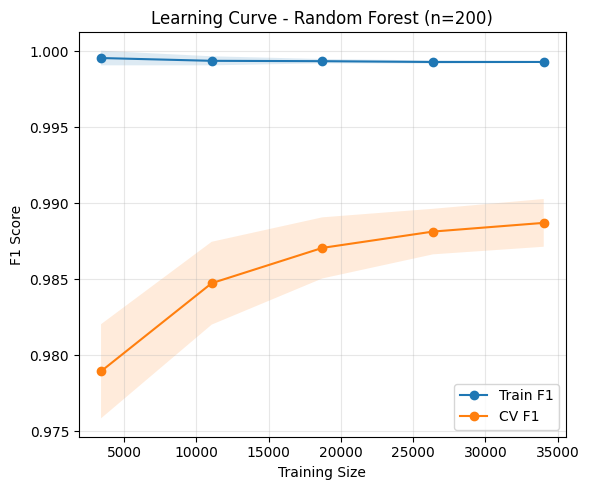

In [ ]:
# ======================================
# LEARNING CURVE CELL (STANDALONE)
# ======================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import learning_curve, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC, SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

# ------------------------
# DATA CONFIG
# ------------------------
DATA_PATH = "/content/drive/MyDrive/ATPM/features.csv"
TARGET_COLUMN = "label"
DROP_EXTRA_COLUMNS = ["Payloads", "Payloads_normalized", "Class"]

# ------------------------
# EXPERIMENT CONFIG
# ------------------------
N_SPLITS = 10
RANDOM_STATE = 42
SCORING = "f1"

TRAIN_SIZES = np.linspace(0.1, 1.0, 5)

# Random Forest
max_depth = None
min_samples_split = 2
n_estimators = 200

# KNN
n_neighbors = 5
weights = 'distance'

# SVM Poly
C_poly = 10
degree = 3
gamma = 'scale'

# SVM Linear
C_linear = 0.1

# ------------------------
# LOAD DATA
# ------------------------
df = pd.read_csv(DATA_PATH, encoding="latin1")

y = df[TARGET_COLUMN].astype(int)

drop_cols = [TARGET_COLUMN]
for c in DROP_EXTRA_COLUMNS:
    if c in df.columns:
        drop_cols.append(c)

X = df.drop(columns=drop_cols)

print("Dataset shape:", X.shape)

# ------------------------
# MODELS
# ------------------------
models = {
    f"SVM linear (C={C_linear})": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LinearSVC(C=C_linear, class_weight="balanced", random_state=RANDOM_STATE)),
    ]),
    f"SVM Poly (deg={degree}, C={C_poly})": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SVC(
            kernel="poly",
            degree=degree,
            C=C_poly,
            gamma=gamma,
            class_weight="balanced",
        )),
    ]),
    f"KNN (k={n_neighbors}, {weights})": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", KNeighborsClassifier(n_neighbors=n_neighbors, weights=weights)),
    ]),
    f"Random Forest (n={n_estimators})": RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        class_weight="balanced_subsample",
        random_state=RANDOM_STATE,
        min_samples_split=min_samples_split,
        n_jobs=-1,
    ),
}

# ------------------------
# CV
# ------------------------
cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

# ------------------------
# LEARNING CURVE FUNCTION
# ------------------------
def plot_learning_curve(model_name, model):

    train_sizes, train_scores, val_scores = learning_curve(
        estimator=model,
        X=X,
        y=y,
        cv=cv,
        scoring=SCORING,
        train_sizes=TRAIN_SIZES,
        shuffle=True,
        n_jobs=-1
    )

    train_mean = train_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)

    val_mean = val_scores.mean(axis=1)
    val_std = val_scores.std(axis=1)

    print("\n", "="*60)
    print("Learning Curve:", model_name)
    print("="*60)

    for s, tr, tr_std, vl, vl_std in zip(train_sizes, train_mean, train_std, val_mean, val_std):
        print(
            f"Train size: {s:6d} | "
            f"Train F1: {tr:.4f} ± {tr_std:.4f} | "
            f"CV F1: {vl:.4f} ± {vl_std:.4f}"
        )

    plt.figure(figsize=(6,5))

    plt.plot(train_sizes, train_mean, marker="o", label="Train F1")
    plt.fill_between(train_sizes, train_mean-train_std, train_mean+train_std, alpha=0.15)

    plt.plot(train_sizes, val_mean, marker="o", label="CV F1")
    plt.fill_between(train_sizes, val_mean-val_std, val_mean+val_std, alpha=0.15)

    plt.xlabel("Training Size")
    plt.ylabel("F1 Score")
    plt.title(f"Learning Curve - {model_name}")

    plt.legend()
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


# ------------------------
# RUN LEARNING CURVES
# ------------------------
for name, model in models.items():
    plot_learning_curve(name, model)

Dataset shape: (37810, 62)

Learning Curve: SVM linear (C=0.01)
Train size:   3024 | Train F1: 0.9788 ± 0.0032 | CV F1: 0.9678 ± 0.0027
Train size:   9830 | Train F1: 0.9764 ± 0.0016 | CV F1: 0.9715 ± 0.0028
Train size:  16636 | Train F1: 0.9755 ± 0.0011 | CV F1: 0.9718 ± 0.0025
Train size:  23442 | Train F1: 0.9742 ± 0.0024 | CV F1: 0.9714 ± 0.0030
Train size:  30248 | Train F1: 0.9737 ± 0.0014 | CV F1: 0.9717 ± 0.0028


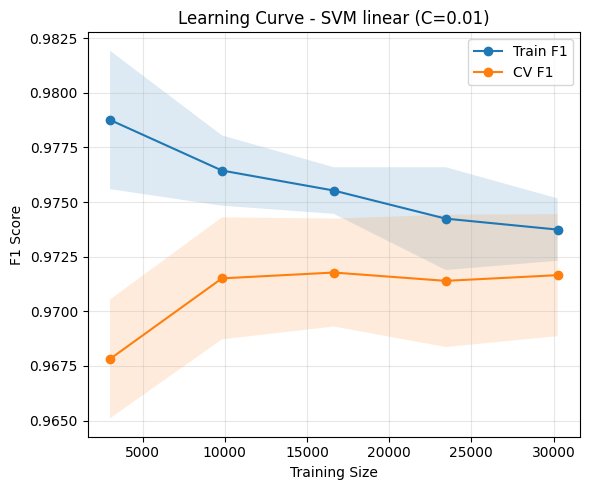


Learning Curve: SVM Poly (deg=3, C=10)
Train size:   3024 | Train F1: 0.9970 ± 0.0010 | CV F1: 0.9688 ± 0.0035
Train size:   9830 | Train F1: 0.9963 ± 0.0006 | CV F1: 0.9809 ± 0.0028
Train size:  16636 | Train F1: 0.9957 ± 0.0006 | CV F1: 0.9835 ± 0.0026
Train size:  23442 | Train F1: 0.9958 ± 0.0007 | CV F1: 0.9851 ± 0.0013
Train size:  30248 | Train F1: 0.9958 ± 0.0004 | CV F1: 0.9868 ± 0.0017


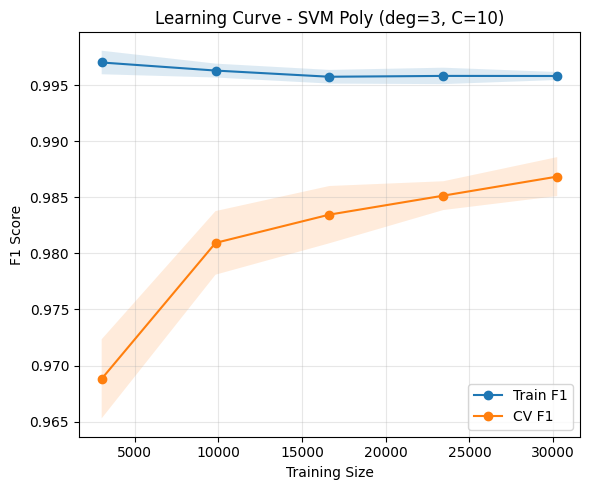


Learning Curve: KNN (k=3, distance)
Train size:   3024 | Train F1: 0.9995 ± 0.0007 | CV F1: 0.9668 ± 0.0020
Train size:   9830 | Train F1: 0.9992 ± 0.0004 | CV F1: 0.9793 ± 0.0021
Train size:  16636 | Train F1: 0.9994 ± 0.0003 | CV F1: 0.9821 ± 0.0018
Train size:  23442 | Train F1: 0.9994 ± 0.0002 | CV F1: 0.9830 ± 0.0016
Train size:  30248 | Train F1: 0.9992 ± 0.0002 | CV F1: 0.9852 ± 0.0015


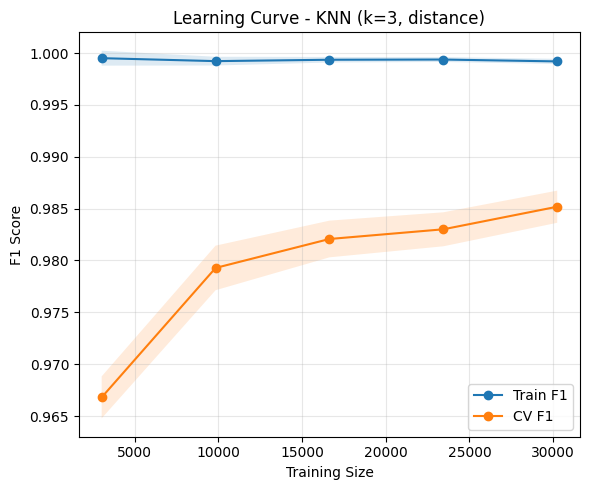


Learning Curve: Random Forest (n=100)
Train size:   3024 | Train F1: 0.9999 ± 0.0002 | CV F1: 0.9769 ± 0.0041
Train size:   9830 | Train F1: 0.9998 ± 0.0001 | CV F1: 0.9838 ± 0.0032
Train size:  16636 | Train F1: 0.9994 ± 0.0001 | CV F1: 0.9860 ± 0.0032
Train size:  23442 | Train F1: 0.9994 ± 0.0002 | CV F1: 0.9875 ± 0.0022
Train size:  30248 | Train F1: 0.9993 ± 0.0002 | CV F1: 0.9885 ± 0.0016


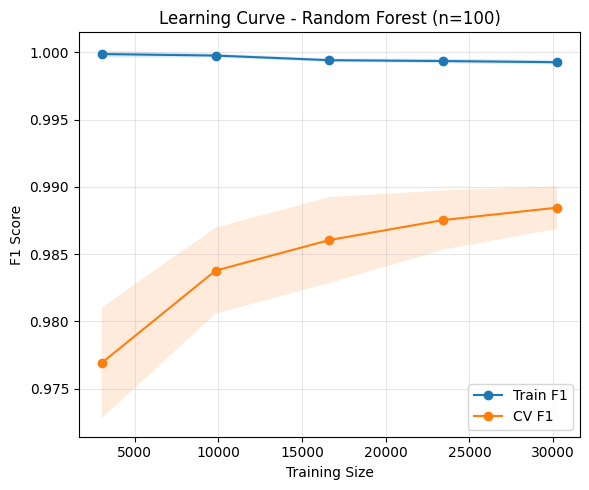

In [ ]:
# ======================================
# LEARNING CURVE CELL (STANDALONE)
# ======================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import learning_curve, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC, SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

# ------------------------
# DATA CONFIG
# ------------------------
DATA_PATH = "/content/drive/MyDrive/ATPM/features.csv"
TARGET_COLUMN = "label"
DROP_EXTRA_COLUMNS = ["Payloads", "Payloads_normalized", "Class"]

# ------------------------
# EXPERIMENT CONFIG
# ------------------------
N_SPLITS = 5
RANDOM_STATE = 42
SCORING = "f1"

TRAIN_SIZES = np.linspace(0.1, 1.0, 5)

# Random Forest
max_depth = None
min_samples_split = 2
n_estimators = 100

# KNN
n_neighbors = 3
weights = 'distance'

# SVM Poly
C_poly = 10
degree = 3
gamma = 'scale'

# SVM Linear
C_linear = 0.01

# ------------------------
# LOAD DATA
# ------------------------
df = pd.read_csv(DATA_PATH, encoding="latin1")

y = df[TARGET_COLUMN].astype(int)

drop_cols = [TARGET_COLUMN]
for c in DROP_EXTRA_COLUMNS:
    if c in df.columns:
        drop_cols.append(c)

X = df.drop(columns=drop_cols)

print("Dataset shape:", X.shape)

# ------------------------
# MODELS
# ------------------------
models = {
    f"SVM linear (C={C_linear})": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LinearSVC(C=C_linear, class_weight="balanced", random_state=RANDOM_STATE)),
    ]),
    f"SVM Poly (deg={degree}, C={C_poly})": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SVC(
            kernel="poly",
            degree=degree,
            C=C_poly,
            gamma=gamma,
            class_weight="balanced",
        )),
    ]),
    f"KNN (k={n_neighbors}, {weights})": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", KNeighborsClassifier(n_neighbors=n_neighbors, weights=weights)),
    ]),
    f"Random Forest (n={n_estimators})": RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        class_weight="balanced_subsample",
        random_state=RANDOM_STATE,
        min_samples_split=min_samples_split,
        n_jobs=-1,
    ),
}

# ------------------------
# CV
# ------------------------
cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

# ------------------------
# LEARNING CURVE FUNCTION
# ------------------------
def plot_learning_curve(model_name, model):

    train_sizes, train_scores, val_scores = learning_curve(
        estimator=model,
        X=X,
        y=y,
        cv=cv,
        scoring=SCORING,
        train_sizes=TRAIN_SIZES,
        shuffle=True,
        n_jobs=-1
    )

    train_mean = train_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)

    val_mean = val_scores.mean(axis=1)
    val_std = val_scores.std(axis=1)

    print("\n", "="*60)
    print("Learning Curve:", model_name)
    print("="*60)

    for s, tr, tr_std, vl, vl_std in zip(train_sizes, train_mean, train_std, val_mean, val_std):
        print(
            f"Train size: {s:6d} | "
            f"Train F1: {tr:.4f} ± {tr_std:.4f} | "
            f"CV F1: {vl:.4f} ± {vl_std:.4f}"
        )

    plt.figure(figsize=(6,5))

    plt.plot(train_sizes, train_mean, marker="o", label="Train F1")
    plt.fill_between(train_sizes, train_mean-train_std, train_mean+train_std, alpha=0.15)

    plt.plot(train_sizes, val_mean, marker="o", label="CV F1")
    plt.fill_between(train_sizes, val_mean-val_std, val_mean+val_std, alpha=0.15)

    plt.xlabel("Training Size")
    plt.ylabel("F1 Score")
    plt.title(f"Learning Curve - {model_name}")

    plt.legend()
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


# ------------------------
# RUN LEARNING CURVES
# ------------------------
for name, model in models.items():
    plot_learning_curve(name, model)

Loaded: (37810, 62)

MODEL: SVM linear (C=0.1)
Fold 01: Acc=0.9897 Sens=0.9887 Spec=0.9900 Prec=0.9718 F1=0.9802 Time=0.46s
Fold 02: Acc=0.9878 Sens=0.9754 Spec=0.9922 Prec=0.9774 F1=0.9764 Time=0.47s
Fold 03: Acc=0.9841 Sens=0.9774 Spec=0.9865 Prec=0.9617 F1=0.9695 Time=0.54s
Fold 04: Acc=0.9810 Sens=0.9764 Spec=0.9825 Prec=0.9510 F1=0.9636 Time=0.46s
Fold 05: Acc=0.9836 Sens=0.9764 Spec=0.9861 Prec=0.9606 F1=0.9685 Time=0.49s
Fold 06: Acc=0.9878 Sens=0.9825 Spec=0.9897 Prec=0.9706 F1=0.9765 Time=0.52s
Fold 07: Acc=0.9857 Sens=0.9805 Spec=0.9875 Prec=0.9646 F1=0.9725 Time=0.53s
Fold 08: Acc=0.9852 Sens=0.9733 Spec=0.9893 Prec=0.9693 F1=0.9713 Time=0.58s
Fold 09: Acc=0.9849 Sens=0.9784 Spec=0.9872 Prec=0.9636 F1=0.9710 Time=0.55s
Fold 10: Acc=0.9865 Sens=0.9795 Spec=0.9890 Prec=0.9685 F1=0.9740 Time=0.58s


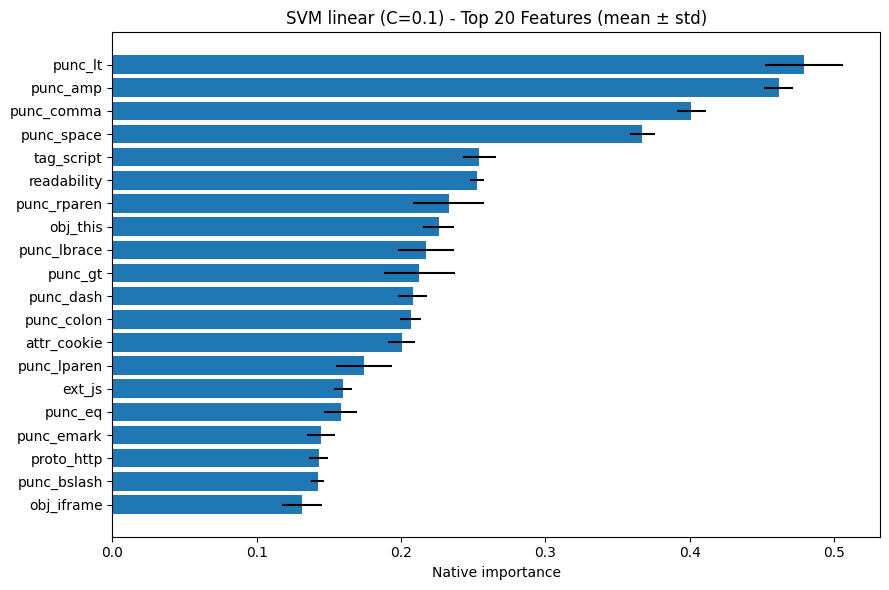

--------------------------------------------------------------------------------
TIME Model: 5.39s
MEAN±STD: Acc=0.9856±0.0024  Sens=0.9789±0.0041  Spec=0.9880±0.0025  Prec=0.9659±0.0069  F1=0.9723±0.0045


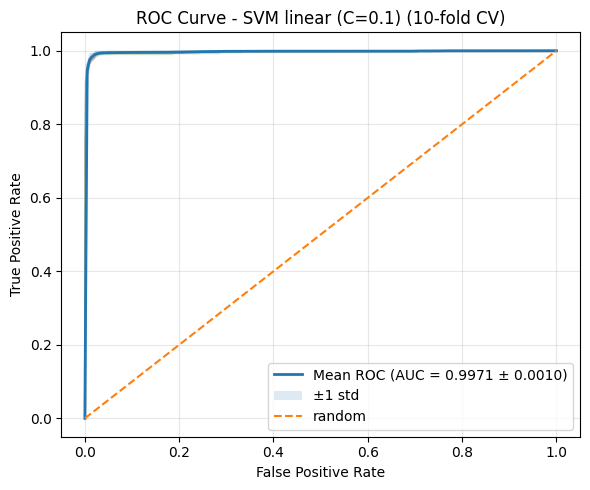

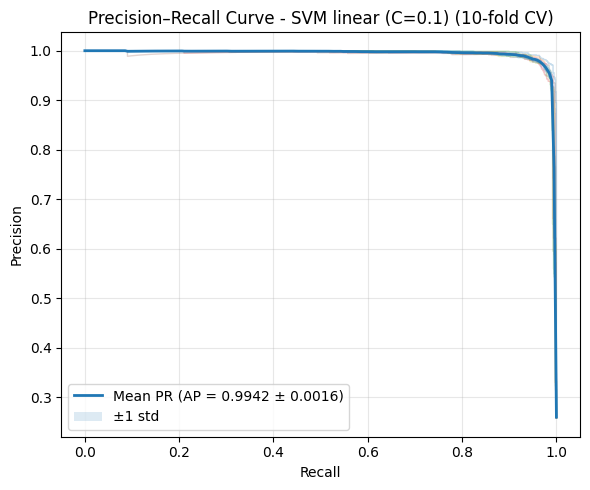


MODEL: SVM Poly (deg=3, C=10)
Fold 01: Acc=0.9952 Sens=0.9959 Spec=0.9950 Prec=0.9858 F1=0.9908 Time=4.42s
Fold 02: Acc=0.9937 Sens=0.9887 Spec=0.9954 Prec=0.9867 F1=0.9877 Time=5.16s
Fold 03: Acc=0.9939 Sens=0.9908 Spec=0.9950 Prec=0.9857 F1=0.9882 Time=4.38s
Fold 04: Acc=0.9913 Sens=0.9867 Spec=0.9929 Prec=0.9796 F1=0.9831 Time=3.99s
Fold 05: Acc=0.9921 Sens=0.9897 Spec=0.9929 Prec=0.9797 F1=0.9847 Time=5.46s
Fold 06: Acc=0.9944 Sens=0.9938 Spec=0.9947 Prec=0.9847 F1=0.9893 Time=4.07s
Fold 07: Acc=0.9923 Sens=0.9877 Spec=0.9939 Prec=0.9826 F1=0.9852 Time=4.13s
Fold 08: Acc=0.9921 Sens=0.9897 Spec=0.9929 Prec=0.9797 F1=0.9847 Time=4.01s
Fold 09: Acc=0.9921 Sens=0.9856 Spec=0.9943 Prec=0.9836 F1=0.9846 Time=5.28s
Fold 10: Acc=0.9934 Sens=0.9887 Spec=0.9950 Prec=0.9857 F1=0.9872 Time=3.95s


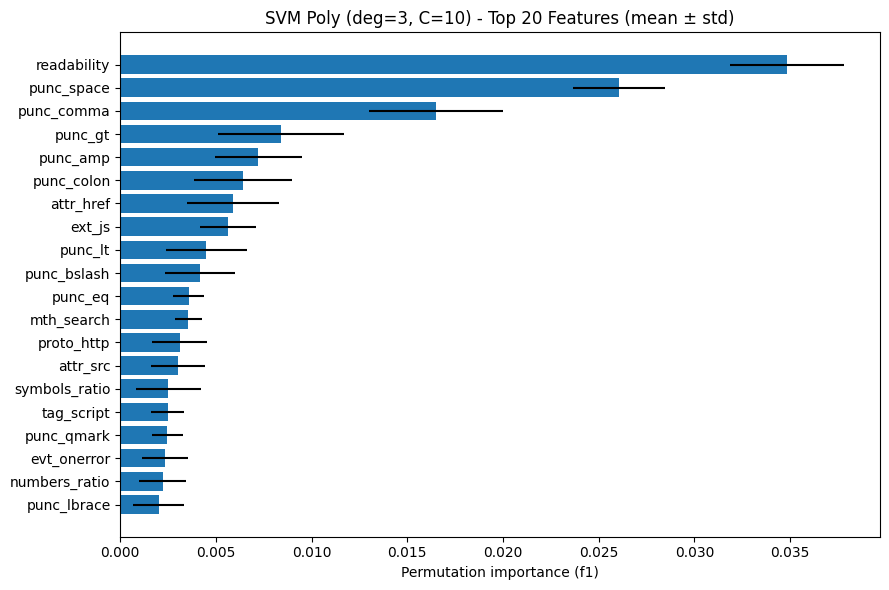

--------------------------------------------------------------------------------
TIME Model: 1435.24s
MEAN±STD: Acc=0.9930±0.0012  Sens=0.9897±0.0030  Spec=0.9942±0.0009  Prec=0.9834±0.0027  F1=0.9865±0.0023


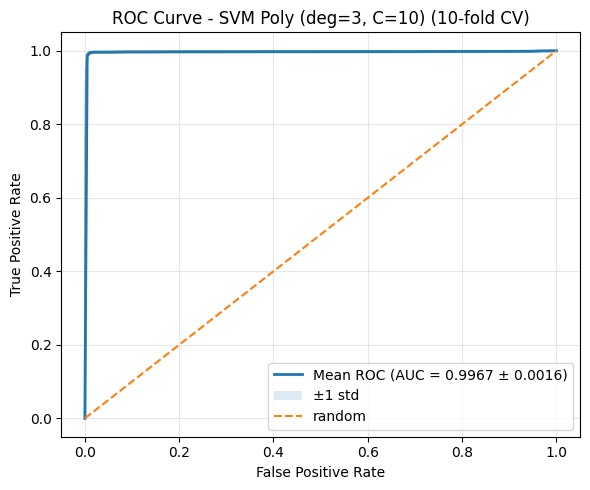

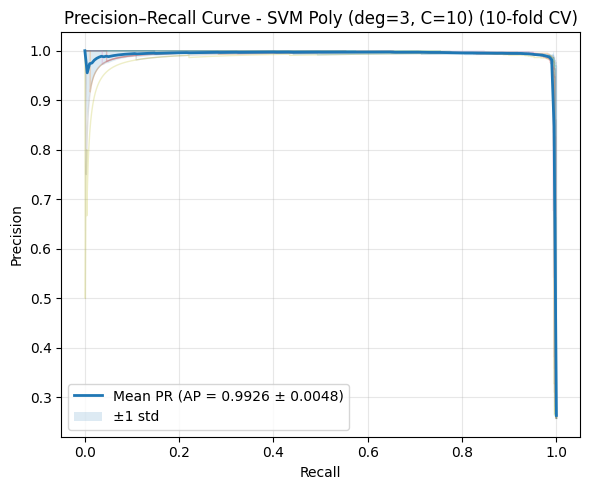


MODEL: KNN (k=5, distance)
Fold 01: Acc=0.9934 Sens=0.9846 Spec=0.9964 Prec=0.9897 F1=0.9871 Time=1.88s
Fold 02: Acc=0.9931 Sens=0.9846 Spec=0.9961 Prec=0.9887 F1=0.9866 Time=1.42s
Fold 03: Acc=0.9929 Sens=0.9836 Spec=0.9961 Prec=0.9887 F1=0.9861 Time=1.22s
Fold 04: Acc=0.9929 Sens=0.9846 Spec=0.9957 Prec=0.9877 F1=0.9861 Time=1.40s
Fold 05: Acc=0.9939 Sens=0.9846 Spec=0.9971 Prec=0.9917 F1=0.9882 Time=1.23s
Fold 06: Acc=0.9931 Sens=0.9815 Spec=0.9971 Prec=0.9917 F1=0.9866 Time=1.21s
Fold 07: Acc=0.9939 Sens=0.9846 Spec=0.9971 Prec=0.9917 F1=0.9882 Time=1.21s
Fold 08: Acc=0.9923 Sens=0.9825 Spec=0.9957 Prec=0.9876 F1=0.9851 Time=1.21s
Fold 09: Acc=0.9902 Sens=0.9754 Spec=0.9954 Prec=0.9865 F1=0.9809 Time=2.18s
Fold 10: Acc=0.9929 Sens=0.9846 Spec=0.9957 Prec=0.9876 F1=0.9861 Time=1.64s


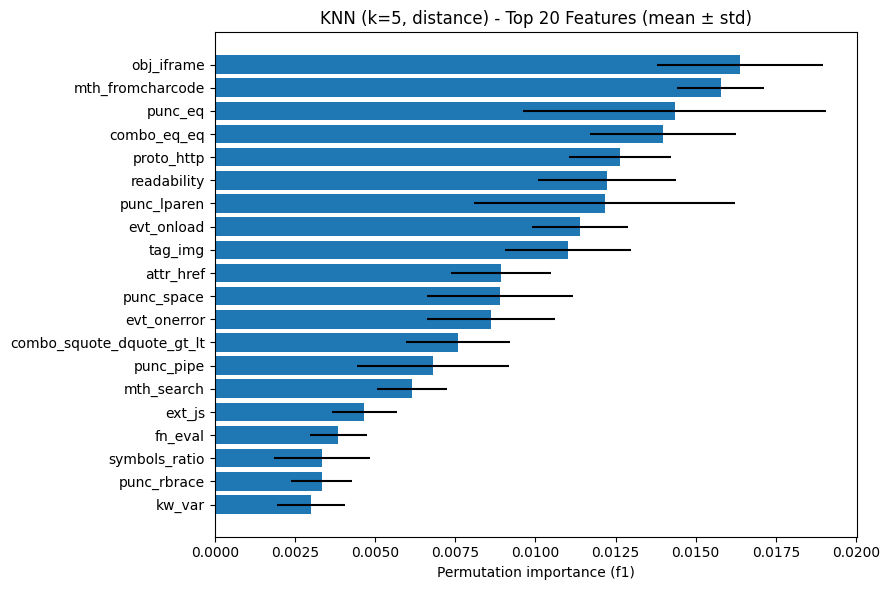

--------------------------------------------------------------------------------
TIME Model: 7942.81s
MEAN±STD: Acc=0.9929±0.0010  Sens=0.9831±0.0028  Spec=0.9963±0.0006  Prec=0.9892±0.0019  F1=0.9861±0.0020


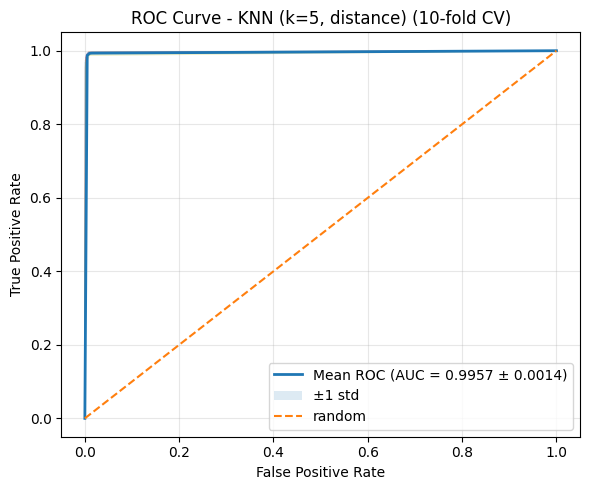

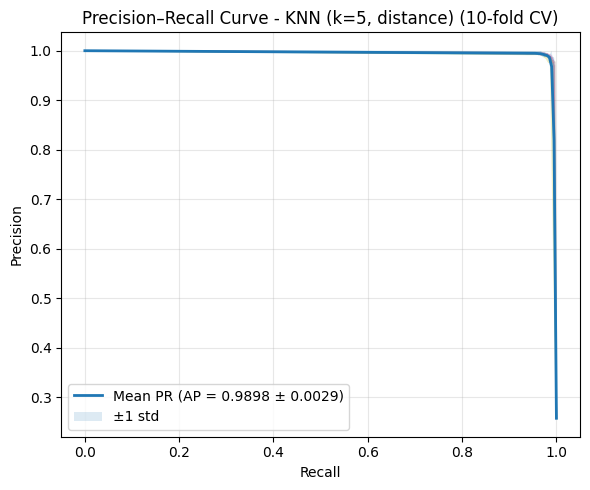


MODEL: Random Forest (n=200)
Fold 01: Acc=0.9942 Sens=0.9897 Spec=0.9957 Prec=0.9877 F1=0.9887 Time=7.13s
Fold 02: Acc=0.9950 Sens=0.9887 Spec=0.9971 Prec=0.9918 F1=0.9902 Time=5.85s
Fold 03: Acc=0.9942 Sens=0.9867 Spec=0.9968 Prec=0.9907 F1=0.9887 Time=7.86s
Fold 04: Acc=0.9939 Sens=0.9867 Spec=0.9964 Prec=0.9897 F1=0.9882 Time=5.88s
Fold 05: Acc=0.9939 Sens=0.9918 Spec=0.9947 Prec=0.9847 F1=0.9882 Time=8.10s
Fold 06: Acc=0.9963 Sens=0.9928 Spec=0.9975 Prec=0.9928 F1=0.9928 Time=5.64s
Fold 07: Acc=0.9942 Sens=0.9877 Spec=0.9964 Prec=0.9897 F1=0.9887 Time=8.09s
Fold 08: Acc=0.9926 Sens=0.9877 Spec=0.9943 Prec=0.9836 F1=0.9857 Time=5.64s
Fold 09: Acc=0.9944 Sens=0.9877 Spec=0.9968 Prec=0.9907 F1=0.9892 Time=7.98s
Fold 10: Acc=0.9952 Sens=0.9908 Spec=0.9968 Prec=0.9908 F1=0.9908 Time=5.67s


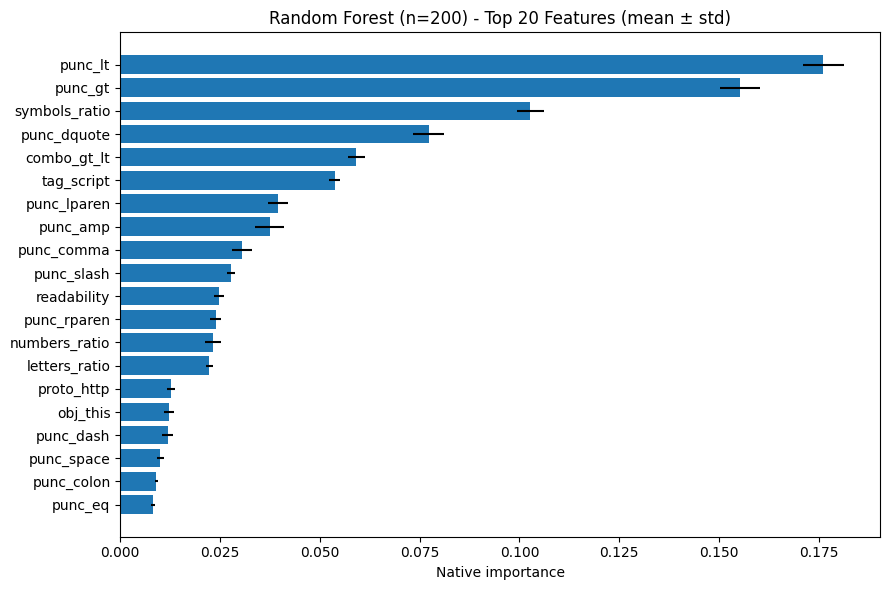

--------------------------------------------------------------------------------
TIME Model: 70.49s
MEAN±STD: Acc=0.9944±0.0009  Sens=0.9890±0.0021  Spec=0.9963±0.0010  Prec=0.9892±0.0028  F1=0.9891±0.0018


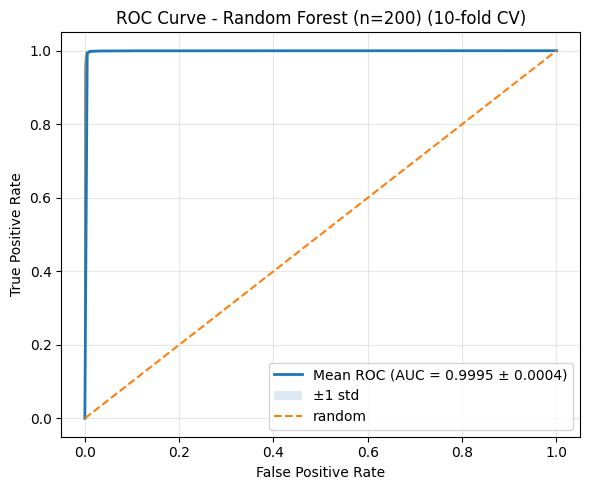

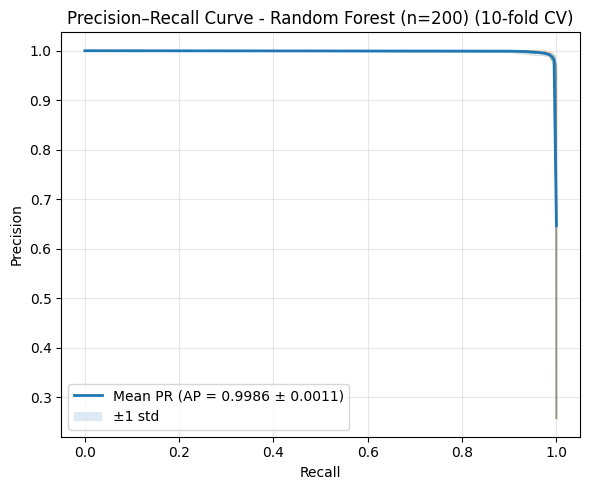



##########################################################################################
CONFUSION MATRICES (POOLED over 10 folds) - Printed Once for All Models
##########################################################################################

Model: SVM linear (C=0.1)


,Predicted Negative(0),Predicted Positive(1)
Actual Negative(0),27728,337
Actual Positive(1),206,9539



Model: SVM Poly (deg=3, C=10)


,Predicted Negative(0),Predicted Positive(1)
Actual Negative(0),27902,163
Actual Positive(1),100,9645



Model: KNN (k=5, distance)


,Predicted Negative(0),Predicted Positive(1)
Actual Negative(0),27960,105
Actual Positive(1),165,9580



Model: Random Forest (n=200)


,Predicted Negative(0),Predicted Positive(1)
Actual Negative(0),27960,105
Actual Positive(1),107,9638


In [ ]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    confusion_matrix,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score,
)
from sklearn.inspection import permutation_importance

# =======================
# Config
# =======================
DATA_PATH = "/content/drive/MyDrive/ATPM/features.csv"
N_SPLITS = 10
RANDOM_STATE = 42

SCORING = "f1"
N_REPEATS = 10
TOP_K = 20
SUBSAMPLE_TEST = 1.0  # 1.0 = no subsample
USE_NATIVE_WHEN_POSSIBLE = True

# Random Forest
max_depth = None
min_samples_split = 2
n_estimators = 200

# KNN
n_neighbors = 5
weights = "distance"

# SVM Poly
C_poly = 10
degree = 3
gamma = "scale"

# SVM Linear

C_linear = 0.1


# =======================
# Utils
# =======================
def safe_display(obj):
    """Display in notebook; fallback to print in script."""
    try:
        from IPython.display import display
        display(obj)
    except Exception:
        print(obj)

def metrics_from_cm(cm):
    TN, FP, FN, TP = cm.ravel()
    # Accuracy = tỷ lệ dự đoán đúng trên toàn bộ dữ liệu
    # Precision = trong các mẫu model dự đoán là positive, có bao nhiêu đúng, tỉ lệ bắt nhầm
    # Recall / Sensitive = model bắt được bao nhiêu positive thật, tỉ lệ bắt chính xác
    # Specificity = khả năng nhận diện đúng negative


    acc = (TP + TN) / (TP + TN + FP + FN) if (TP + TN + FP + FN) else 0.0
    sens = TP / (TP + FN) if (TP + FN) else 0.0  # recall / TPR
    spec = TN / (TN + FP) if (TN + FP) else 0.0  # TNR
    prec = TP / (TP + FP) if (TP + FP) else 0.0
    f1 = (2 * prec * sens / (prec + sens)) if (prec + sens) else 0.0

    return acc, sens, spec, prec, f1

def labeled_cm_df(cm):
    return pd.DataFrame(
        cm,
        index=["Actual Negative(0)", "Actual Positive(1)"],
        columns=["Predicted Negative(0)", "Predicted Positive(1)"],
    )

def get_pos_scores(fitted_model, X_):
    """Scores for positive class to draw ROC/PR.
    Prefer predict_proba, else decision_function, else predict.
    """
    if hasattr(fitted_model, "predict_proba"):
        return fitted_model.predict_proba(X_)[:, 1]
    if hasattr(fitted_model, "decision_function"):
        return fitted_model.decision_function(X_)
    return fitted_model.predict(X_)

def get_final_estimator(m):
    if isinstance(m, Pipeline):
        return m.named_steps.get("clf", m)
    return m

def native_importance(fitted_model, feature_names):
    """Return pd.Series of native importances if available, else None."""
    est = get_final_estimator(fitted_model)

    if hasattr(est, "feature_importances_"):
        return pd.Series(est.feature_importances_, index=feature_names)

    if hasattr(est, "coef_"):
        coef = np.asarray(est.coef_, dtype=float)
        imp = np.mean(np.abs(coef), axis=0)  # handles binary + multiclass
        return pd.Series(imp, index=feature_names)

    return None

def subsample_xy(Xt, yt, frac, seed=42):
    """Xt, yt: pandas objects."""
    if frac >= 1.0:
        return Xt, yt
    n = len(yt)
    k = max(10, int(n * frac))
    rng = np.random.default_rng(seed)
    idx = rng.choice(n, size=k, replace=False)
    return Xt.iloc[idx], yt.iloc[idx]

def plot_topk_importance(model_name, imp_df, top_k, used_native, scoring):
    top_df = imp_df.head(top_k).iloc[::-1]
    plt.figure(figsize=(9, 6))
    plt.barh(top_df["feature"], top_df["importance_mean"], xerr=top_df["importance_std"])
    xlabel = "Native importance" if used_native else f"Permutation importance ({scoring})"
    plt.xlabel(xlabel)
    plt.title(f"{model_name} - Top {top_k} Features (mean ± std)")
    plt.tight_layout()
    plt.show()

def plot_roc_pr_cv(model_name, y_true_folds, y_score_folds, n_splits, plot_folds=True):
    """
    Plot ROC + PR as mean ± std across CV folds.
    y_true_folds, y_score_folds: list of arrays, one per fold (test set only).
    """
    # ---------- ROC ----------
    fpr_grid = np.linspace(0, 1, 200)
    tprs = []
    aucs = []

    plt.figure(figsize=(6, 5))

    for yt, ys in zip(y_true_folds, y_score_folds):
        fpr, tpr, _ = roc_curve(yt, ys)
        roc_auc = auc(fpr, tpr)
        aucs.append(roc_auc)

        tpr_i = np.interp(fpr_grid, fpr, tpr)
        tpr_i[0] = 0.0
        tprs.append(tpr_i)

        if plot_folds:
            plt.plot(fpr, tpr, alpha=0.25, linewidth=1)

    tprs = np.vstack(tprs)
    mean_tpr = tprs.mean(axis=0)
    std_tpr = tprs.std(axis=0)
    mean_tpr[-1] = 1.0

    mean_auc = float(np.mean(aucs))
    std_auc = float(np.std(aucs))

    plt.plot(
        fpr_grid,
        mean_tpr,
        label=f"Mean ROC (AUC = {mean_auc:.4f} ± {std_auc:.4f})",
        linewidth=2,
    )
    plt.fill_between(
        fpr_grid,
        np.clip(mean_tpr - std_tpr, 0, 1),
        np.clip(mean_tpr + std_tpr, 0, 1),
        alpha=0.15,
        label="±1 std",
    )
    plt.plot([0, 1], [0, 1], linestyle="--", label="random")

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {model_name} ({n_splits}-fold CV)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # ---------- Precision–Recall ----------
    recall_grid = np.linspace(0, 1, 200)
    precisions_interp = []
    aps = []

    plt.figure(figsize=(6, 5))

    for yt, ys in zip(y_true_folds, y_score_folds):
        precision, recall, _ = precision_recall_curve(yt, ys)
        ap = average_precision_score(yt, ys)
        aps.append(ap)

        order = np.argsort(recall)
        recall_sorted = recall[order]
        precision_sorted = precision[order]

        prec_i = np.interp(recall_grid, recall_sorted, precision_sorted)
        precisions_interp.append(prec_i)

        if plot_folds:
            plt.plot(recall, precision, alpha=0.25, linewidth=1)

    precisions_interp = np.vstack(precisions_interp)
    mean_prec = precisions_interp.mean(axis=0)
    std_prec = precisions_interp.std(axis=0)

    mean_ap = float(np.mean(aps))
    std_ap = float(np.std(aps))

    plt.plot(
        recall_grid,
        mean_prec,
        label=f"Mean PR (AP = {mean_ap:.4f} ± {std_ap:.4f})",
        linewidth=2,
    )
    plt.fill_between(
        recall_grid,
        np.clip(mean_prec - std_prec, 0, 1),
        np.clip(mean_prec + std_prec, 0, 1),
        alpha=0.15,
        label="±1 std",
    )

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision–Recall Curve - {model_name} ({n_splits}-fold CV)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# =======================
# Load dataset
# =======================
df = pd.read_csv(DATA_PATH, encoding="latin1")
assert "label" in df.columns, "Missing 'label' column."

y = df["label"].astype(int)

drop_cols = ["label"]
for c in ["Payloads", "Payloads_normalized", "Class"]:
    if c in df.columns:
        drop_cols.append(c)

X = df.drop(columns=drop_cols)
feature_cols = X.columns

print("Loaded:", X.shape)

# =======================
# Define models
# =======================
# NOTE: StandardScaler() for dense X (DataFrame). If X becomes sparse later, switch to with_mean=False.
models = {
    f"SVM linear (C={C_linear})": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LinearSVC(C=C_linear, class_weight="balanced", random_state=RANDOM_STATE)),
    ]),
    f"SVM Poly (deg={degree}, C={C_poly})": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SVC(
            kernel="poly",
            degree=degree,
            C=C_poly,
            gamma=gamma,
            class_weight="balanced",
        )),
    ]),
    f"KNN (k={n_neighbors}, {weights})": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", KNeighborsClassifier(n_neighbors=n_neighbors, weights=weights)),
    ]),
    f"Random Forest (n={n_estimators})": RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        class_weight="balanced_subsample",
        random_state=RANDOM_STATE,
        min_samples_split=min_samples_split,
        n_jobs=-1,
    ),
}

# =======================
# CV splits
# =======================
kf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
splits = list(kf.split(X, y))

perm_results = {}
final_confusions = {}

# =======================
# Run all models
# =======================
for model_name, base_estimator in models.items():
    print("\n" + "=" * 80)
    print(f"MODEL: {model_name}")
    print("=" * 80)

    fold_imps = []
    used_native = False
    fold_scores = []

    all_true, all_pred, all_score = [], [], []

    t_model_start = time.perf_counter()

    for fold_idx, (train_idx, test_idx) in enumerate(splits, start=1):
        m = clone(base_estimator)

        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        t0 = time.perf_counter()
        m.fit(X_train, y_train)
        y_pred = m.predict(X_test)
        t1 = time.perf_counter()
        fold_time = t1 - t0

        y_score = get_pos_scores(m, X_test)

        cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
        acc, sens, spec, prec, f1 = metrics_from_cm(cm)
        fold_scores.append((acc, sens, spec, prec, f1))

        all_true.append(y_test.to_numpy())
        all_pred.append(np.asarray(y_pred))
        all_score.append(np.asarray(y_score))

        print(
            f"Fold {fold_idx:02d}: "
            f"Acc={acc:.4f} Sens={sens:.4f} Spec={spec:.4f} "
            f"Prec={prec:.4f} F1={f1:.4f} "
            f"Time={fold_time:.2f}s"
        )

        # ===== Feature importance =====
        imp_s = None
        if USE_NATIVE_WHEN_POSSIBLE:
            imp_s = native_importance(m, feature_cols)

        if imp_s is not None:
            used_native = True
            fold_imps.append(imp_s.reindex(feature_cols).fillna(0.0).to_numpy())
        else:
            X_t, y_t = subsample_xy(X_test, y_test, SUBSAMPLE_TEST, seed=RANDOM_STATE + fold_idx)
            r = permutation_importance(
                m,
                X_t,
                y_t,
                n_repeats=N_REPEATS,
                random_state=RANDOM_STATE + fold_idx,
                scoring=SCORING,
                n_jobs=-1,
            )
            fold_imps.append(r.importances_mean)

    total_model_time = time.perf_counter() - t_model_start

    # ===== Importance aggregation =====
    fold_imps = np.vstack(fold_imps)
    mean_imp = fold_imps.mean(axis=0)
    std_imp = fold_imps.std(axis=0)

    imp_df = pd.DataFrame({
        "feature": feature_cols,
        "importance_mean": mean_imp,
        "importance_std": std_imp,
        "stability_cv": std_imp / (np.abs(mean_imp) + 1e-12),
    }).sort_values(["importance_mean", "stability_cv"], ascending=[False, True])

    perm_results[model_name] = imp_df
    plot_topk_importance(model_name, imp_df, TOP_K, used_native, SCORING)

    # ===== Metrics aggregation =====
    arr = np.array(fold_scores)
    means = arr.mean(axis=0)
    stds = arr.std(axis=0)

    print("-" * 80)
    print(f"TIME Model: {total_model_time:.2f}s")
    print(
        f"MEAN±STD: "
        f"Acc={means[0]:.4f}±{stds[0]:.4f}  "
        f"Sens={means[1]:.4f}±{stds[1]:.4f}  "
        f"Spec={means[2]:.4f}±{stds[2]:.4f}  "
        f"Prec={means[3]:.4f}±{stds[3]:.4f}  "
        f"F1={means[4]:.4f}±{stds[4]:.4f}"
    )

    # ===== ROC/PR mean±std across folds =====
    plot_roc_pr_cv(
        model_name=model_name,
        y_true_folds=all_true,
        y_score_folds=all_score,
        n_splits=N_SPLITS,
        plot_folds=True,
    )

    # ===== Pooled CM =====
    y_true_all = np.concatenate(all_true)
    y_pred_all = np.concatenate(all_pred)
    cm_all = confusion_matrix(y_true_all, y_pred_all, labels=[0, 1])
    final_confusions[model_name] = labeled_cm_df(cm_all)

# =======================
# Print Confusion Matrices ONCE at the end
# =======================
print("\n\n" + "#" * 90)
print(f"CONFUSION MATRICES (POOLED over {N_SPLITS} folds) - Printed Once for All Models")
print("#" * 90)

for model_name, cm_df in final_confusions.items():
    print("\nModel:", model_name)
    safe_display(cm_df)

Loaded: (37810, 62)

MODEL: SVM linear (C=0.01)
Fold 01: Acc=0.9872 Sens=0.9810 Spec=0.9893 Prec=0.9696 F1=0.9753 Time=0.58s
Fold 02: Acc=0.9828 Sens=0.9754 Spec=0.9854 Prec=0.9586 F1=0.9669 Time=0.54s
Fold 03: Acc=0.9848 Sens=0.9769 Spec=0.9875 Prec=0.9645 F1=0.9707 Time=0.53s
Fold 04: Acc=0.9856 Sens=0.9764 Spec=0.9888 Prec=0.9680 F1=0.9722 Time=0.60s
Fold 05: Acc=0.9861 Sens=0.9795 Spec=0.9884 Prec=0.9671 F1=0.9732 Time=0.56s


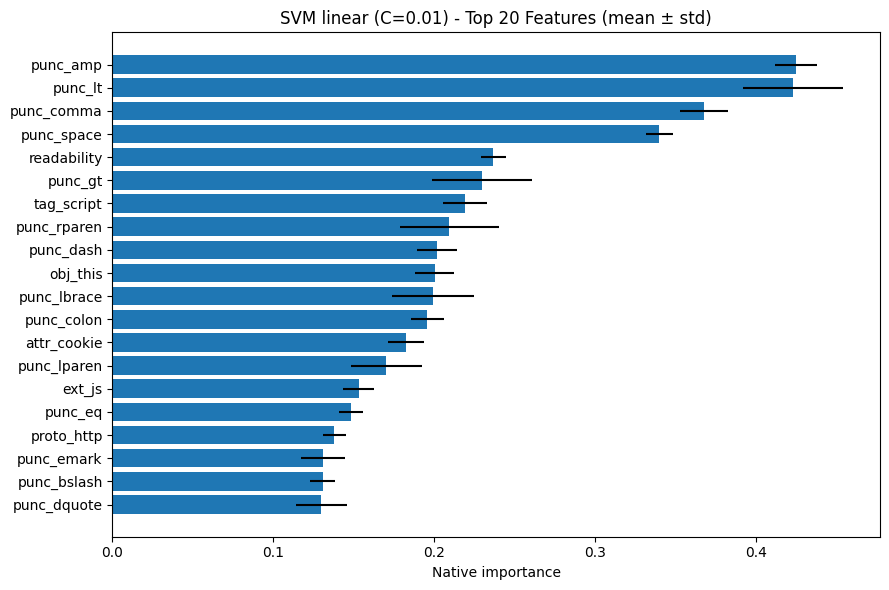

--------------------------------------------------------------------------------
TIME Model: 2.97s
MEAN±STD: Acc=0.9853±0.0015  Sens=0.9778±0.0021  Spec=0.9879±0.0014  Prec=0.9656±0.0038  F1=0.9717±0.0028


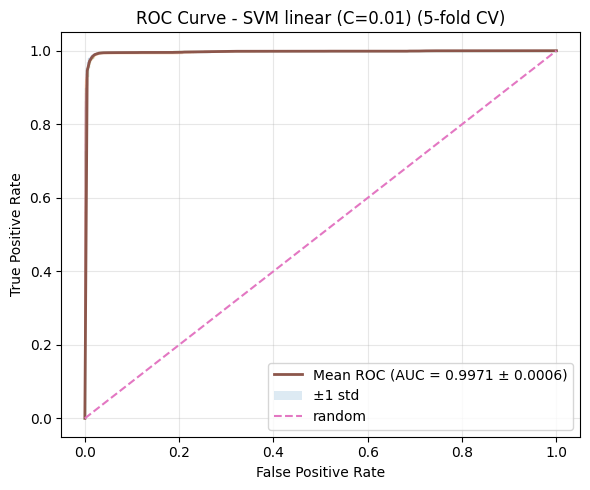

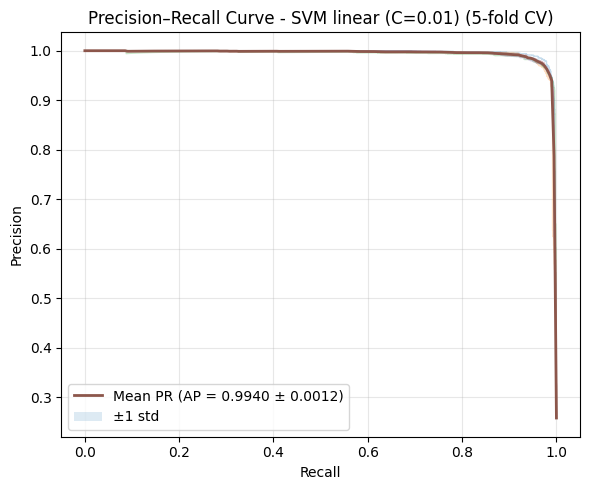


MODEL: SVM Poly (deg=3, C=10)
Fold 01: Acc=0.9943 Sens=0.9918 Spec=0.9952 Prec=0.9862 F1=0.9890 Time=4.62s
Fold 02: Acc=0.9923 Sens=0.9861 Spec=0.9945 Prec=0.9841 F1=0.9851 Time=3.61s
Fold 03: Acc=0.9942 Sens=0.9923 Spec=0.9948 Prec=0.9852 F1=0.9888 Time=4.71s
Fold 04: Acc=0.9922 Sens=0.9887 Spec=0.9934 Prec=0.9812 F1=0.9849 Time=3.51s
Fold 05: Acc=0.9930 Sens=0.9877 Spec=0.9948 Prec=0.9852 F1=0.9864 Time=4.11s


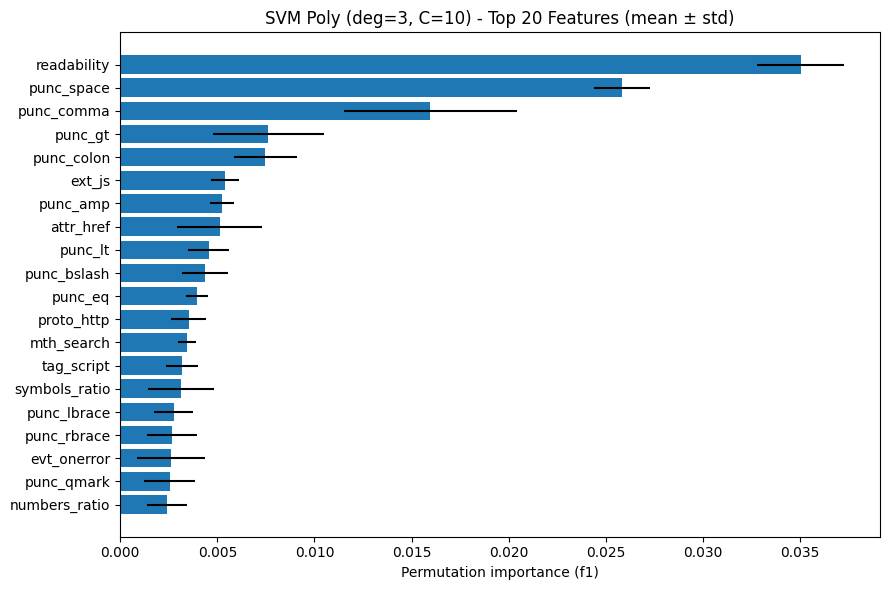

--------------------------------------------------------------------------------
TIME Model: 1237.75s
MEAN±STD: Acc=0.9932±0.0009  Sens=0.9893±0.0024  Spec=0.9945±0.0006  Prec=0.9844±0.0017  F1=0.9868±0.0017


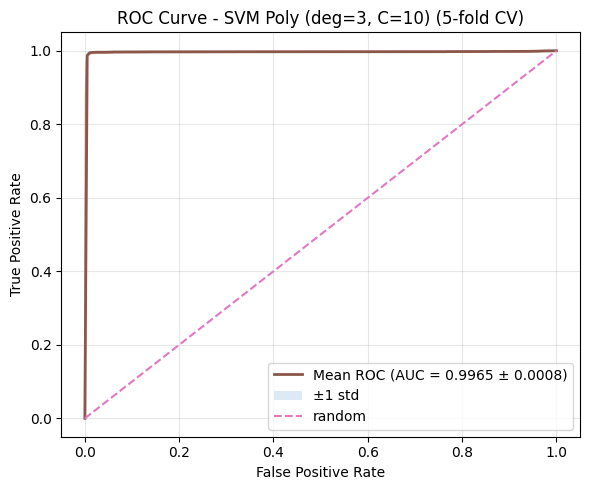

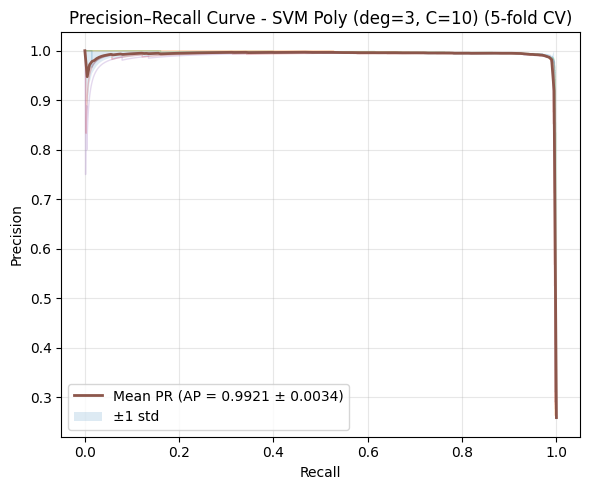


MODEL: KNN (k=3, distance)
Fold 01: Acc=0.9930 Sens=0.9836 Spec=0.9963 Prec=0.9892 F1=0.9864 Time=2.42s
Fold 02: Acc=0.9911 Sens=0.9800 Spec=0.9950 Prec=0.9856 F1=0.9828 Time=3.39s
Fold 03: Acc=0.9937 Sens=0.9841 Spec=0.9970 Prec=0.9912 F1=0.9876 Time=1.88s
Fold 04: Acc=0.9926 Sens=0.9836 Spec=0.9957 Prec=0.9876 F1=0.9856 Time=1.91s
Fold 05: Acc=0.9921 Sens=0.9841 Spec=0.9948 Prec=0.9851 F1=0.9846 Time=3.11s


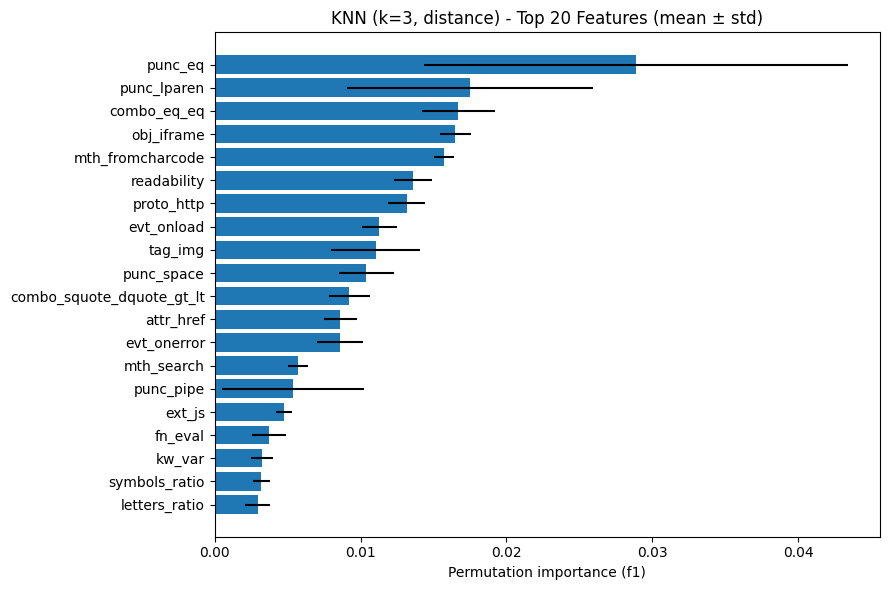

--------------------------------------------------------------------------------
TIME Model: 6339.13s
MEAN±STD: Acc=0.9925±0.0009  Sens=0.9831±0.0016  Spec=0.9958±0.0008  Prec=0.9877±0.0023  F1=0.9854±0.0016


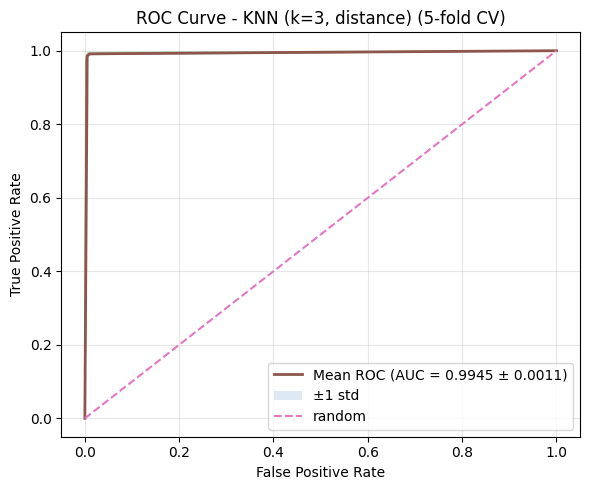

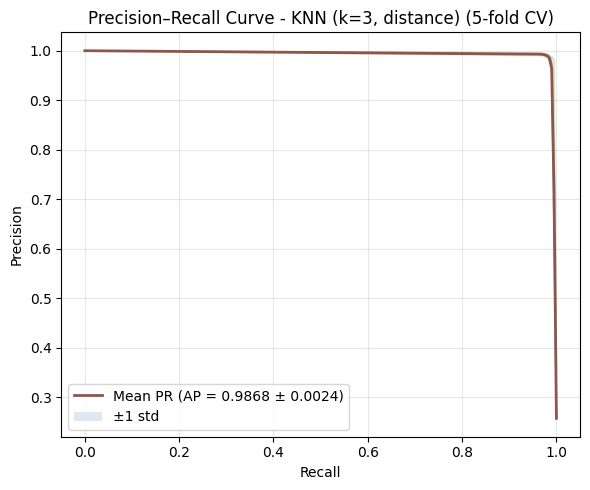


MODEL: Random Forest (n=100)
Fold 01: Acc=0.9950 Sens=0.9892 Spec=0.9970 Prec=0.9913 F1=0.9902 Time=2.71s
Fold 02: Acc=0.9933 Sens=0.9867 Spec=0.9955 Prec=0.9872 F1=0.9869 Time=3.98s
Fold 03: Acc=0.9948 Sens=0.9913 Spec=0.9961 Prec=0.9887 F1=0.9900 Time=3.54s
Fold 04: Acc=0.9937 Sens=0.9887 Spec=0.9954 Prec=0.9867 F1=0.9877 Time=3.01s
Fold 05: Acc=0.9947 Sens=0.9897 Spec=0.9964 Prec=0.9897 F1=0.9897 Time=2.60s


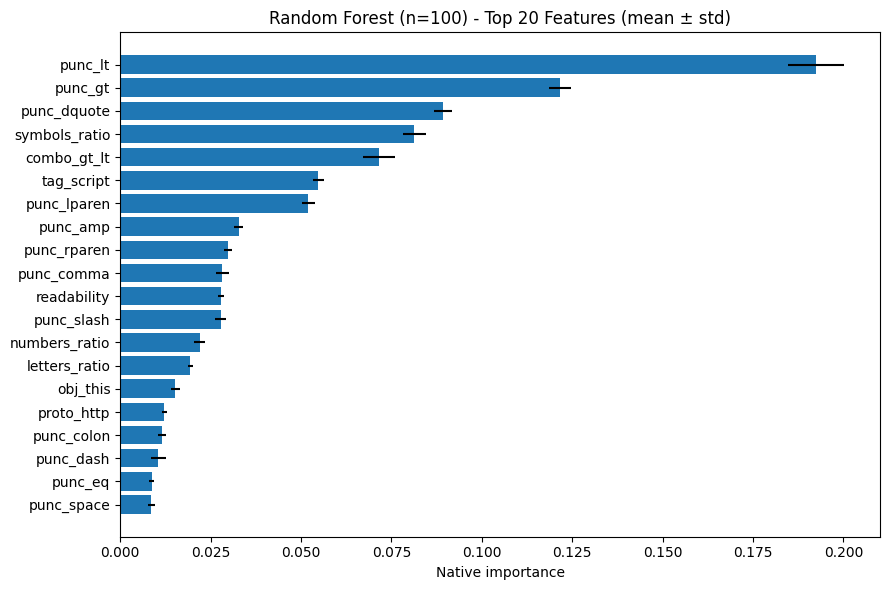

--------------------------------------------------------------------------------
TIME Model: 16.82s
MEAN±STD: Acc=0.9943±0.0007  Sens=0.9891±0.0015  Spec=0.9961±0.0006  Prec=0.9887±0.0017  F1=0.9889±0.0014


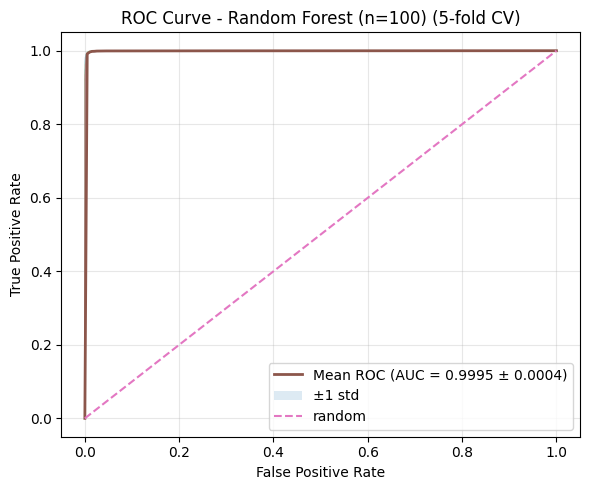

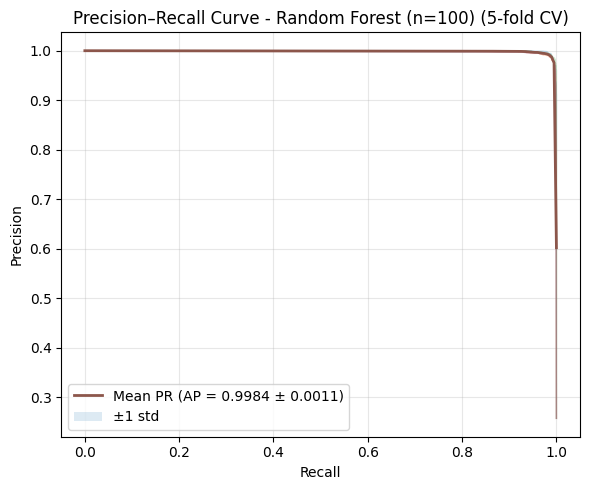



##########################################################################################
CONFUSION MATRICES (POOLED over 5 folds) - Printed Once for All Models
##########################################################################################

Model: SVM linear (C=0.01)


,Predicted Negative(0),Predicted Positive(1)
Actual Negative(0),27725,340
Actual Positive(1),216,9529



Model: SVM Poly (deg=3, C=10)


,Predicted Negative(0),Predicted Positive(1)
Actual Negative(0),27912,153
Actual Positive(1),104,9641



Model: KNN (k=3, distance)


,Predicted Negative(0),Predicted Positive(1)
Actual Negative(0),27946,119
Actual Positive(1),165,9580



Model: Random Forest (n=100)


,Predicted Negative(0),Predicted Positive(1)
Actual Negative(0),27955,110
Actual Positive(1),106,9639


In [3]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    confusion_matrix,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score,
)
from sklearn.inspection import permutation_importance

# =======================
# Config
# =======================
DATA_PATH = "/content/drive/MyDrive/ATPM/features.csv"
N_SPLITS = 5
RANDOM_STATE = 42

SCORING = "f1"
N_REPEATS = 10
TOP_K = 20
SUBSAMPLE_TEST = 1.0  # 1.0 = no subsample
USE_NATIVE_WHEN_POSSIBLE = True

# Random Forest
max_depth = None
min_samples_split = 2
n_estimators = 100

# KNN
n_neighbors = 3
weights = "distance"

# SVM Poly
C_poly = 10
degree = 3
gamma = "scale"

# SVM Linear

C_linear = 0.01


# =======================
# Utils
# =======================
def safe_display(obj):
    """Display in notebook; fallback to print in script."""
    try:
        from IPython.display import display
        display(obj)
    except Exception:
        print(obj)

def metrics_from_cm(cm):
    TN, FP, FN, TP = cm.ravel()
    # Accuracy = tỷ lệ dự đoán đúng trên toàn bộ dữ liệu
    # Precision = trong các mẫu model dự đoán là positive, có bao nhiêu đúng, tỉ lệ bắt nhầm
    # Recall / Sensitive = model bắt được bao nhiêu positive thật, tỉ lệ bắt chính xác
    # Specificity = khả năng nhận diện đúng negative


    acc = (TP + TN) / (TP + TN + FP + FN) if (TP + TN + FP + FN) else 0.0
    sens = TP / (TP + FN) if (TP + FN) else 0.0  # recall / TPR
    spec = TN / (TN + FP) if (TN + FP) else 0.0  # TNR
    prec = TP / (TP + FP) if (TP + FP) else 0.0
    f1 = (2 * prec * sens / (prec + sens)) if (prec + sens) else 0.0

    return acc, sens, spec, prec, f1

def labeled_cm_df(cm):
    return pd.DataFrame(
        cm,
        index=["Actual Negative(0)", "Actual Positive(1)"],
        columns=["Predicted Negative(0)", "Predicted Positive(1)"],
    )

def get_pos_scores(fitted_model, X_):
    """Scores for positive class to draw ROC/PR.
    Prefer predict_proba, else decision_function, else predict.
    """
    if hasattr(fitted_model, "predict_proba"):
        return fitted_model.predict_proba(X_)[:, 1]
    if hasattr(fitted_model, "decision_function"):
        return fitted_model.decision_function(X_)
    return fitted_model.predict(X_)

def get_final_estimator(m):
    if isinstance(m, Pipeline):
        return m.named_steps.get("clf", m)
    return m

def native_importance(fitted_model, feature_names):
    """Return pd.Series of native importances if available, else None."""
    est = get_final_estimator(fitted_model)

    if hasattr(est, "feature_importances_"):
        return pd.Series(est.feature_importances_, index=feature_names)

    if hasattr(est, "coef_"):
        coef = np.asarray(est.coef_, dtype=float)
        imp = np.mean(np.abs(coef), axis=0)  # handles binary + multiclass
        return pd.Series(imp, index=feature_names)

    return None

def subsample_xy(Xt, yt, frac, seed=42):
    """Xt, yt: pandas objects."""
    if frac >= 1.0:
        return Xt, yt
    n = len(yt)
    k = max(10, int(n * frac))
    rng = np.random.default_rng(seed)
    idx = rng.choice(n, size=k, replace=False)
    return Xt.iloc[idx], yt.iloc[idx]

def plot_topk_importance(model_name, imp_df, top_k, used_native, scoring):
    top_df = imp_df.head(top_k).iloc[::-1]
    plt.figure(figsize=(9, 6))
    plt.barh(top_df["feature"], top_df["importance_mean"], xerr=top_df["importance_std"])
    xlabel = "Native importance" if used_native else f"Permutation importance ({scoring})"
    plt.xlabel(xlabel)
    plt.title(f"{model_name} - Top {top_k} Features (mean ± std)")
    plt.tight_layout()
    plt.show()

def plot_roc_pr_cv(model_name, y_true_folds, y_score_folds, n_splits, plot_folds=True):
    """
    Plot ROC + PR as mean ± std across CV folds.
    y_true_folds, y_score_folds: list of arrays, one per fold (test set only).
    """
    # ---------- ROC ----------
    fpr_grid = np.linspace(0, 1, 200)
    tprs = []
    aucs = []

    plt.figure(figsize=(6, 5))

    for yt, ys in zip(y_true_folds, y_score_folds):
        fpr, tpr, _ = roc_curve(yt, ys)
        roc_auc = auc(fpr, tpr)
        aucs.append(roc_auc)

        tpr_i = np.interp(fpr_grid, fpr, tpr)
        tpr_i[0] = 0.0
        tprs.append(tpr_i)

        if plot_folds:
            plt.plot(fpr, tpr, alpha=0.25, linewidth=1)

    tprs = np.vstack(tprs)
    mean_tpr = tprs.mean(axis=0)
    std_tpr = tprs.std(axis=0)
    mean_tpr[-1] = 1.0

    mean_auc = float(np.mean(aucs))
    std_auc = float(np.std(aucs))

    plt.plot(
        fpr_grid,
        mean_tpr,
        label=f"Mean ROC (AUC = {mean_auc:.4f} ± {std_auc:.4f})",
        linewidth=2,
    )
    plt.fill_between(
        fpr_grid,
        np.clip(mean_tpr - std_tpr, 0, 1),
        np.clip(mean_tpr + std_tpr, 0, 1),
        alpha=0.15,
        label="±1 std",
    )
    plt.plot([0, 1], [0, 1], linestyle="--", label="random")

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {model_name} ({n_splits}-fold CV)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # ---------- Precision–Recall ----------
    recall_grid = np.linspace(0, 1, 200)
    precisions_interp = []
    aps = []

    plt.figure(figsize=(6, 5))

    for yt, ys in zip(y_true_folds, y_score_folds):
        precision, recall, _ = precision_recall_curve(yt, ys)
        ap = average_precision_score(yt, ys)
        aps.append(ap)

        order = np.argsort(recall)
        recall_sorted = recall[order]
        precision_sorted = precision[order]

        prec_i = np.interp(recall_grid, recall_sorted, precision_sorted)
        precisions_interp.append(prec_i)

        if plot_folds:
            plt.plot(recall, precision, alpha=0.25, linewidth=1)

    precisions_interp = np.vstack(precisions_interp)
    mean_prec = precisions_interp.mean(axis=0)
    std_prec = precisions_interp.std(axis=0)

    mean_ap = float(np.mean(aps))
    std_ap = float(np.std(aps))

    plt.plot(
        recall_grid,
        mean_prec,
        label=f"Mean PR (AP = {mean_ap:.4f} ± {std_ap:.4f})",
        linewidth=2,
    )
    plt.fill_between(
        recall_grid,
        np.clip(mean_prec - std_prec, 0, 1),
        np.clip(mean_prec + std_prec, 0, 1),
        alpha=0.15,
        label="±1 std",
    )

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision–Recall Curve - {model_name} ({n_splits}-fold CV)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# =======================
# Load dataset
# =======================
df = pd.read_csv(DATA_PATH, encoding="latin1")
assert "label" in df.columns, "Missing 'label' column."

y = df["label"].astype(int)

drop_cols = ["label"]
for c in ["Payloads", "Payloads_normalized", "Class"]:
    if c in df.columns:
        drop_cols.append(c)

X = df.drop(columns=drop_cols)
feature_cols = X.columns

print("Loaded:", X.shape)

# =======================
# Define models
# =======================
# NOTE: StandardScaler() for dense X (DataFrame). If X becomes sparse later, switch to with_mean=False.
models = {
    f"SVM linear (C={C_linear})": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LinearSVC(C=C_linear, class_weight="balanced", random_state=RANDOM_STATE)),
    ]),
    f"SVM Poly (deg={degree}, C={C_poly})": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SVC(
            kernel="poly",
            degree=degree,
            C=C_poly,
            gamma=gamma,
            class_weight="balanced",
        )),
    ]),
    f"KNN (k={n_neighbors}, {weights})": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", KNeighborsClassifier(n_neighbors=n_neighbors, weights=weights)),
    ]),
    f"Random Forest (n={n_estimators})": RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        class_weight="balanced_subsample",
        random_state=RANDOM_STATE,
        min_samples_split=min_samples_split,
        n_jobs=-1,
    ),
}

# =======================
# CV splits
# =======================
kf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
splits = list(kf.split(X, y))

perm_results = {}
final_confusions = {}

# =======================
# Run all models
# =======================
for model_name, base_estimator in models.items():
    print("\n" + "=" * 80)
    print(f"MODEL: {model_name}")
    print("=" * 80)

    fold_imps = []
    used_native = False
    fold_scores = []

    all_true, all_pred, all_score = [], [], []

    t_model_start = time.perf_counter()

    for fold_idx, (train_idx, test_idx) in enumerate(splits, start=1):
        m = clone(base_estimator)

        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        t0 = time.perf_counter()
        m.fit(X_train, y_train)
        y_pred = m.predict(X_test)
        t1 = time.perf_counter()
        fold_time = t1 - t0

        y_score = get_pos_scores(m, X_test)

        cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
        acc, sens, spec, prec, f1 = metrics_from_cm(cm)
        fold_scores.append((acc, sens, spec, prec, f1))

        all_true.append(y_test.to_numpy())
        all_pred.append(np.asarray(y_pred))
        all_score.append(np.asarray(y_score))

        print(
            f"Fold {fold_idx:02d}: "
            f"Acc={acc:.4f} Sens={sens:.4f} Spec={spec:.4f} "
            f"Prec={prec:.4f} F1={f1:.4f} "
            f"Time={fold_time:.2f}s"
        )

        # ===== Feature importance =====
        imp_s = None
        if USE_NATIVE_WHEN_POSSIBLE:
            imp_s = native_importance(m, feature_cols)

        if imp_s is not None:
            used_native = True
            fold_imps.append(imp_s.reindex(feature_cols).fillna(0.0).to_numpy())
        else:
            X_t, y_t = subsample_xy(X_test, y_test, SUBSAMPLE_TEST, seed=RANDOM_STATE + fold_idx)
            r = permutation_importance(
                m,
                X_t,
                y_t,
                n_repeats=N_REPEATS,
                random_state=RANDOM_STATE + fold_idx,
                scoring=SCORING,
                n_jobs=-1,
            )
            fold_imps.append(r.importances_mean)

    total_model_time = time.perf_counter() - t_model_start

    # ===== Importance aggregation =====
    fold_imps = np.vstack(fold_imps)
    mean_imp = fold_imps.mean(axis=0)
    std_imp = fold_imps.std(axis=0)

    imp_df = pd.DataFrame({
        "feature": feature_cols,
        "importance_mean": mean_imp,
        "importance_std": std_imp,
        "stability_cv": std_imp / (np.abs(mean_imp) + 1e-12),
    }).sort_values(["importance_mean", "stability_cv"], ascending=[False, True])

    perm_results[model_name] = imp_df
    plot_topk_importance(model_name, imp_df, TOP_K, used_native, SCORING)

    # ===== Metrics aggregation =====
    arr = np.array(fold_scores)
    means = arr.mean(axis=0)
    stds = arr.std(axis=0)

    print("-" * 80)
    print(f"TIME Model: {total_model_time:.2f}s")
    print(
        f"MEAN±STD: "
        f"Acc={means[0]:.4f}±{stds[0]:.4f}  "
        f"Sens={means[1]:.4f}±{stds[1]:.4f}  "
        f"Spec={means[2]:.4f}±{stds[2]:.4f}  "
        f"Prec={means[3]:.4f}±{stds[3]:.4f}  "
        f"F1={means[4]:.4f}±{stds[4]:.4f}"
    )

    # ===== ROC/PR mean±std across folds =====
    plot_roc_pr_cv(
        model_name=model_name,
        y_true_folds=all_true,
        y_score_folds=all_score,
        n_splits=N_SPLITS,
        plot_folds=True,
    )

    # ===== Pooled CM =====
    y_true_all = np.concatenate(all_true)
    y_pred_all = np.concatenate(all_pred)
    cm_all = confusion_matrix(y_true_all, y_pred_all, labels=[0, 1])
    final_confusions[model_name] = labeled_cm_df(cm_all)

# =======================
# Print Confusion Matrices ONCE at the end
# =======================
print("\n\n" + "#" * 90)
print(f"CONFUSION MATRICES (POOLED over {N_SPLITS} folds) - Printed Once for All Models")
print("#" * 90)

for model_name, cm_df in final_confusions.items():
    print("\nModel:", model_name)
    safe_display(cm_df)